<div class="ng-cover" style="background:#14283f;color:#fff;padding:34px 38px;border-radius:16px;border-left:8px solid #20b7a5">
<div style="font-size:12px;letter-spacing:3px;color:#83e1d5">NETWORK TRAFFIC · MACHINE LEARNING · REPRODUCIBLE RESEARCH</div>
<h1 style="color:#fff;font-size:42px;margin:12px 0 8px">NetGuard</h1>
<p style="font-size:20px;margin:0 0 16px;color:#e3edf4">From raw connections to an explainable anomaly detection report.</p>
<p style="max-width:760px;color:#bfd0df">One notebook brings together data exploration, physical features, anomaly detection,
supervised comparisons, evaluation, and portable predictions. Every implementation is included below.</p>
</div>

# Network anomaly detection, end to end

**Research question:** how much attack traffic can we detect while limiting false alarms on normal connections?

This report uses the two supplied UNSW-NB15 CSVs. Models learn from a grouped development partition.
Validation chooses the decision threshold under a **1% empirical false-positive budget**.
The supplied testing CSV has been inspected previously and is presented as a benchmark.

**Start here:** choose the notebook environment, then **Restart Kernel → Run All**.
Only the two original CSVs are needed at runtime. All feature, model, evaluation, plotting,
and persistence code lives in this file; no project Python imports are required.

| Chapter | What you will learn |
|:--|:--|
| [01 · Setup](#setup) | Reproducible settings and where to place the CSVs |
| [02 · Explore](#explore) | Class balance, missingness, distributions, and dataset shift |
| [03 · Prepare](#prepare) | Grouped partitions and 29 physical features |
| [04 · Upgraded models](#supervised) | CatBoost, XGBoost, LightGBM, Extra Trees, MLP, TabM, and references |
| [05 · Neural learning](#anomaly) | MLP and TabM learning curves and optional historical experiments |
| [06 · Evaluate](#evaluate) | Confusion matrices, ROC/PR curves, false alarms, and attack families |
| [07 · Robustness](#robustness) | Seen/unseen signatures, uncertainty, and optional withheld-family runs |
| [08 · Predict & export](#export) | A complete portable model, row predictions, and a run manifest |
| [09 · Conclusions](#conclusions) | Measured findings, practical limits, and next steps |

The former seven stage notebooks have been consolidated. Their original source text is retained
in this notebook's `netguard_consolidation.legacy_sources` metadata for traceability.
Old generated outputs and duplicated merge cells are excluded from the report.

<a id="setup"></a>
## 01 · Setup and reproducibility

Use **Python 3.13.9** with the project's `requirements-notebooks.txt` for the exact environment.
For a standalone copy, install the following packages before starting the kernel:

```text
numpy==2.2.6 pandas==2.2.3 scipy==1.15.3 scikit-learn==1.6.1
joblib==1.4.2 threadpoolctl==3.6.0 matplotlib==3.10.3 cloudpickle==3.1.1
catboost==1.2.8 xgboost==3.0.5 lightgbm==4.7.0
torch==2.8.0 tabm==0.0.3 rtdl_num_embeddings==0.0.12
nbformat==5.10.4 nbclient==0.10.2 ipykernel==6.29.5
```

Place `UNSW_NB15_training-set.csv` and `UNSW_NB15_testing-set.csv` beside this notebook
or in a `data/` directory beside it or its parent. You can also set `NETGUARD_DATA_DIR`.
The setup cell reports any version differences and fails clearly if an essential package is missing.
Running the report creates `netguard_outputs/` beside the data directory by default.
In this project the runner chooses `artifacts/notebook_report/`.

The upgraded supervised comparison, including a neural network, runs by default. Legacy anomaly experiments are optional. Expensive t-SNE and repeated
withheld-family refits are optional switches in the settings cell. They are never silently skipped.

In [1]:
from pathlib import Path
from importlib.metadata import version
from dataclasses import dataclass, asdict
from datetime import datetime, timezone
from hashlib import sha256
from functools import lru_cache
from html import escape
import io
import json
import os
import platform
import time
import warnings

import cloudpickle
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import HTML, Markdown, display
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.manifold import TSNE
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.neural_network import MLPRegressor, MLPClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import torch
from tabm import TabM
from sklearn.preprocessing import StandardScaler
from sklearn.utils.validation import check_is_fitted
from threadpoolctl import threadpool_limits

EXPECTED_VERSIONS = {
    "numpy": "2.2.6", "pandas": "2.2.3", "scipy": "1.15.3", "scikit-learn": "1.6.1",
    "joblib": "1.4.2", "threadpoolctl": "3.6.0", "matplotlib": "3.10.3", "cloudpickle": "3.1.1", "catboost": "1.2.8", "xgboost": "3.0.5",
    "lightgbm": "4.7.0", "torch": "2.8.0", "tabm": "0.0.3", "rtdl-num-embeddings": "0.0.12",
}
environment = pd.DataFrame([
    {"package": package, "expected": expected, "installed": version(package),
     "matches": version(package) == expected} for package, expected in EXPECTED_VERSIONS.items()
])
if not environment.matches.all() or platform.python_version() != "3.13.9":
    warnings.warn("This runtime differs from the reproducible lock. Results and model compatibility may differ.")
print(f"Python {platform.python_version()} | all analysis implementations are embedded in this notebook")
display(environment)

Python 3.13.9 | all analysis implementations are embedded in this notebook


,package,expected,installed,matches
0,numpy,2.2.6,2.2.6,True
1,pandas,2.2.3,2.2.3,True
2,scipy,1.15.3,1.15.3,True
3,scikit-learn,1.6.1,1.6.1,True
4,joblib,1.4.2,1.4.2,True
5,threadpoolctl,3.6.0,3.6.0,True
6,matplotlib,3.10.3,3.10.3,True
7,cloudpickle,3.1.1,3.1.1,True
8,catboost,1.2.8,1.2.8,True
9,xgboost,3.0.5,3.0.5,True


In [2]:
COLORS = {"ink": "#14283f", "muted": "#65788b", "normal": "#119c8c", "attack": "#df784c",
          "blue": "#4a78ba", "purple": "#8674b8", "grid": "#e4ebf1", "paper": "#f6f9fc"}
plt.rcParams.update({
    "figure.figsize": (11, 4.5), "figure.dpi": 110, "savefig.dpi": 130,
    "font.family": "DejaVu Sans", "font.size": 10, "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.labelcolor": COLORS["muted"],
    "axes.edgecolor": COLORS["grid"], "axes.spines.top": False, "axes.spines.right": False,
    "text.color": COLORS["ink"], "xtick.color": COLORS["muted"], "ytick.color": COLORS["muted"],
    "grid.color": COLORS["grid"], "axes.axisbelow": True, "figure.facecolor": "white",
})
pd.set_option("display.max_columns", 12)
pd.set_option("display.max_rows", 35)
pd.set_option("display.precision", 4)
display(HTML('''<style>
.ng-cards{display:flex;flex-wrap:wrap;gap:12px;margin:18px 0}
.ng-card{flex:1;min-width:155px;border:1px solid #e0e9f0;border-top:3px solid #119c8c;
border-radius:10px;padding:16px 20px;background:#f6f9fc;color:#14283f}
.ng-card strong{display:block;font-size:25px;padding:5px 0}
.ng-card small{color:#65788b}.ng-note{padding:15px 20px;border-left:4px solid #119c8c;
background:#f6f9fc;color:#14283f;border-radius:0 8px 8px 0;margin:15px 0}
.ng-table{overflow-x:auto;margin:14px 0}.ng-table table{border-collapse:collapse;font-size:12px;width:100%;color:#14283f}
.ng-table th{background:#14283f;color:white;text-align:left;padding:10px}
.ng-table td{padding:9px;border-bottom:1px solid #e4ebf1}.ng-table tr:nth-child(even){background:#f6f9fc}
</style>'''))

def cards(items):
    blocks = [f'<div class="ng-card"><small>{escape(str(label))}</small>'
              f'<strong>{escape(str(value))}</strong><small>{escape(str(note))}</small></div>'
              for label, value, note in items]
    display(HTML('<div class="ng-cards">' + ''.join(blocks) + '</div>'))

def note(text):
    display(HTML('<div class="ng-note">' + escape(str(text)) + '</div>'))

def show_table(frame, percent=(), decimals=3):
    formatting = {column: ("{:,." + str(decimals) + "f}").format for column in frame.select_dtypes("float").columns}
    formatting.update({column: "{:.2%}".format for column in percent if column in frame})
    display(HTML('<div class="ng-table">' + frame.to_html(index=False, formatters=formatting, na_rep="—", escape=True) + '</div>'))

def finish_figure(fig, name):
    fig.tight_layout()
    fig.savefig(OUTPUT / "figures" / f"{name}.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)

### Included implementations

The compact cells below define the complete analysis pipeline. They are collapsed where supported;
expand them to inspect formulas or model code. They execute normally during **Run All**.
Feature validation, grouped splits, tied-score threshold selection, and ensemble policies follow
the project's tested workflow. The notebook saves its own portable research artifact in its output folder.

In [3]:
import numpy as np

import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin

FEATURE_SCHEMA_VERSION = 2

MAX_EXACT_COUNT = 2**53 - 1

RAW_INPUTS = (
    "sbytes", "dbytes", "spkts", "dpkts", "dur", "rate",
    "sload", "dload", "sttl", "dttl",
)

DERIVED_INPUTS = (
    "bytes_total", "pkts_total", "bytes_per_pkt_src", "bytes_per_pkt_dst",
    "bytes_ratio", "bytes_ratio_smoothed", "bytes_diff_normalized",
    "src_zero_pkts", "dst_zero_pkts", "dst_zero_bytes", "zero_total_bytes",
    "src_low_ttl", "dst_low_ttl", "log1p_sbytes", "log1p_dbytes",
    "log1p_dur", "log1p_rate", "log1p_sload", "log1p_dload",
)

FEATURE_NAMES = RAW_INPUTS + DERIVED_INPUTS

COUNT_INPUTS = ("sbytes", "dbytes", "spkts", "dpkts")

LOG_INPUTS = ("sbytes", "dbytes", "dur", "rate", "sload", "dload")

INDICATORS = (
    "src_zero_pkts", "dst_zero_pkts", "dst_zero_bytes", "zero_total_bytes",
    "src_low_ttl", "dst_low_ttl",
)

def _safe_divide(numerator, denominator):
    """Return zero for an undefined zero denominator; companion flags retain it."""
    return np.divide(
        numerator, denominator, out=np.zeros(len(numerator), dtype=np.float64),
        where=np.asarray(denominator) > 0,
    )

class RawTrafficFeatures(TransformerMixin, BaseEstimator):
    """A stateless float64 transformation of ten measured raw input fields.

    Exact totals keep byte/packet units. Undefined ratios have a zero sentinel
    plus an explicit flag; they are not interpreted as observed zero ratios.
    The smoothed byte ratio uses one byte as a declared pseudocount. TTL flags
    are candidate predictors and do not independently classify an attack.
    """

    def fit(self, X, y=None):
        self.feature_schema_version_ = FEATURE_SCHEMA_VERSION
        self.transform(X)
        self.n_features_in_ = len(RAW_INPUTS)
        self.feature_names_in_ = np.asarray(RAW_INPUTS, dtype=object)
        return self

    def transform(self, X):
        if hasattr(self, "n_features_in_") and getattr(self, "feature_schema_version_", None) != FEATURE_SCHEMA_VERSION:
            raise ValueError("This model uses an earlier feature schema; retrain from raw data.")
        if not isinstance(X, pd.DataFrame):
            raise TypeError("Supply raw measurements as a pandas DataFrame.")
        if not X.columns.is_unique:
            raise ValueError("Raw measurement column names must be unique.")
        missing = sorted(set(RAW_INPUTS) - set(X.columns))
        if missing:
            raise ValueError(f"Missing required raw measurements: {missing}")
        f = X.loc[:, list(RAW_INPUTS)].astype(np.float64).copy()
        values = f.to_numpy()
        if not np.isfinite(values).all() or (values < 0).any():
            raise ValueError("Raw measurements must be finite and nonnegative.")
        for col in (*COUNT_INPUTS, "sttl", "dttl"):
            if (f[col] != np.floor(f[col])).any():
                raise ValueError(f"{col} must contain integer measurements.")
        if (f.loc[:, ["sttl", "dttl"]] > 255).any().any():
            raise ValueError("TTL measurements must be between 0 and 255.")
        if (f.loc[:, list(COUNT_INPUTS)] > MAX_EXACT_COUNT).any().any():
            raise ValueError("Byte/packet counts exceed exact float64 integer precision.")
        f["bytes_total"] = f.sbytes + f.dbytes
        f["pkts_total"] = f.spkts + f.dpkts
        if (f.loc[:, ["bytes_total", "pkts_total"]] > MAX_EXACT_COUNT).any().any():
            raise ValueError("Byte/packet totals exceed exact float64 integer precision.")
        for direction, byte_col, packet_col in (
            ("src", "sbytes", "spkts"), ("dst", "dbytes", "dpkts")
        ):
            f[f"bytes_per_pkt_{direction}"] = _safe_divide(f[byte_col], f[packet_col])
            f[f"{direction}_zero_pkts"] = (f[packet_col] == 0).astype(np.float64)
        f["bytes_ratio"] = _safe_divide(f.sbytes, f.dbytes)
        f["dst_zero_bytes"] = (f.dbytes == 0).astype(np.float64)
        f["bytes_ratio_smoothed"] = (f.sbytes + 1.0) / (f.dbytes + 1.0)
        f["bytes_diff_normalized"] = _safe_divide(f.sbytes - f.dbytes, f.bytes_total)
        f["zero_total_bytes"] = (f.bytes_total == 0).astype(np.float64)
        f["src_low_ttl"] = ((f.sttl > 0) & (f.sttl < 10)).astype(np.float64)
        f["dst_low_ttl"] = ((f.dttl > 0) & (f.dttl < 10)).astype(np.float64)
        for col in LOG_INPUTS:
            # One reference unit (byte, second, or the supplied rate/load unit).
            f[f"log1p_{col}"] = np.log1p(f[col])
        result = f.loc[:, list(FEATURE_NAMES)]
        if not np.isfinite(result.to_numpy()).all():
            raise ValueError("Feature calculations overflowed; check raw measurements.")
        return result

    def get_feature_names_out(self, input_features=None):
        return np.asarray(FEATURE_NAMES, dtype=object)

def feature_catalog():
    """Return the definition of every unscaled model input, in fitted feature order."""
    raw = {
        "sbytes": ("Source-to-destination byte count", "bytes"),
        "dbytes": ("Destination-to-source byte count", "bytes"),
        "spkts": ("Source-to-destination packet count", "packets"),
        "dpkts": ("Destination-to-source packet count", "packets"),
        "dur": ("Recorded connection duration", "seconds"),
        "rate": ("Connection rate supplied by the dataset; not recomputed", "original dataset rate units"),
        "sload": ("Recorded source load; not recomputed", "original dataset load units"),
        "dload": ("Recorded destination load; not recomputed", "original dataset load units"),
        "sttl": ("Recorded source packet time-to-live value", "TTL value"),
        "dttl": ("Recorded destination packet time-to-live value", "TTL value"),
    }
    rows = {}
    for name, (meaning, unit) in raw.items():
        rows[name] = {"feature": name, "meaning": meaning, "unit": unit,
                      "formula": "measured raw input", "zero_policy": "Retain recorded zero; never substitute a median."}
    definitions = {
        "bytes_total": ("Total recorded bytes in both directions", "bytes", "sbytes + dbytes", "0 when both byte counts are 0."),
        "pkts_total": ("Total recorded packets in both directions", "packets", "spkts + dpkts", "0 when both packet counts are 0."),
        "bytes_per_pkt_src": ("Source bytes per recorded source packet", "bytes/packet", "sbytes / spkts", "If spkts=0, use 0 sentinel and src_zero_pkts=1."),
        "bytes_per_pkt_dst": ("Destination bytes per recorded destination packet", "bytes/packet", "dbytes / dpkts", "If dpkts=0, use 0 sentinel and dst_zero_pkts=1."),
        "bytes_ratio": ("Exact source/destination byte ratio when defined", "dimensionless", "sbytes / dbytes", "If dbytes=0, use 0 sentinel and dst_zero_bytes=1."),
        "bytes_ratio_smoothed": ("Source/destination byte ratio with a one-byte pseudocount", "dimensionless", "(sbytes + 1 byte) / (dbytes + 1 byte)", "Always defined; both zero gives 1. This is a smoothed ratio, not an exact measured ratio."),
        "bytes_diff_normalized": ("Signed directional byte balance: -1 destination-only, +1 source-only", "dimensionless [-1, 1]", "(sbytes - dbytes) / bytes_total", "If bytes_total=0, use 0 sentinel and zero_total_bytes=1."),
        "src_zero_pkts": ("Source bytes-per-packet denominator is zero", "binary 0/1", "1 if spkts == 0 else 0", "1 includes both all-zero and inconsistent positive-byte/zero-packet inputs."),
        "dst_zero_pkts": ("Destination bytes-per-packet denominator is zero", "binary 0/1", "1 if dpkts == 0 else 0", "1 includes both all-zero and inconsistent positive-byte/zero-packet inputs."),
        "dst_zero_bytes": ("Exact byte-ratio denominator is zero", "binary 0/1", "1 if dbytes == 0 else 0", "Disambiguates the undefined-ratio sentinel from a measured zero ratio."),
        "zero_total_bytes": ("No recorded bytes in either direction", "binary 0/1", "1 if bytes_total == 0 else 0", "Disambiguates undefined byte balance from equal nonzero byte counts."),
        "src_low_ttl": ("Candidate low source TTL indicator; does not prove an attack", "binary 0/1", "1 if 0 < sttl < 10 else 0", "TTL=0 is not marked low. No missing TTL is inferred."),
        "dst_low_ttl": ("Candidate low destination TTL indicator; does not prove an attack", "binary 0/1", "1 if 0 < dttl < 10 else 0", "TTL=0 is not marked low. No missing TTL is inferred."),
    }
    for name, (meaning, unit, formula, zero_policy) in definitions.items():
        rows[name] = {"feature": name, "meaning": meaning, "unit": unit,
                      "formula": formula, "zero_policy": zero_policy}
    for name in LOG_INPUTS:
        key = f"log1p_{name}"
        rows[key] = {
            "feature": key, "meaning": f"Natural-log compression of raw {name}; no clipping of scaled values",
            "unit": "dimensionless log value",
            "formula": f"ln(1 + {name} / 1 reference unit [{raw[name][1]}])",
            "zero_policy": "Raw zero maps to zero. Negative/nonfinite raw measurements are rejected.",
        }
    return [rows[name] for name in FEATURE_NAMES]

def feature_quality_report(raw, features=None):
    """Assert raw physical invariants and return compact full-dataset evidence."""
    f = RawTrafficFeatures().transform(raw) if features is None else features
    if list(f.columns) != list(FEATURE_NAMES) or not f.index.equals(raw.index):
        raise AssertionError("Feature order and row index must match the raw input contract.")
    checks = {
        "all_values_finite": bool(np.isfinite(f.to_numpy()).all()),
        "raw_measurements_unchanged": bool(np.array_equal(
            f.loc[:, list(RAW_INPUTS)].to_numpy(), raw.loc[:, list(RAW_INPUTS)].to_numpy(dtype=np.float64)
        )),
        "byte_total_matches_raw": bool(np.array_equal(f.bytes_total, raw.sbytes + raw.dbytes)),
        "packet_total_matches_raw": bool(np.array_equal(f.pkts_total, raw.spkts + raw.dpkts)),
        "nonnegative_integer_counts": bool(all(
            ((f[col] >= 0) & (f[col] == np.floor(f[col]))).all()
            for col in (*COUNT_INPUTS, "bytes_total", "pkts_total")
        )),
        "nonnegative_features_except_signed_byte_balance": bool(
            (f.drop(columns="bytes_diff_normalized") >= 0).all().all()
        ),
        "signed_byte_balance_in_bounds": bool(f.bytes_diff_normalized.between(-1, 1).all()),
        "indicators_binary": bool(f.loc[:, list(INDICATORS)].isin([0, 1]).all().all()),
        "ttl_values_in_range": bool(f.loc[:, ["sttl", "dttl"]].ge(0).all().all() and
                                    f.loc[:, ["sttl", "dttl"]].le(255).all().all()),
    }
    for direction, byte_col, packet_col in (("src", "sbytes", "spkts"), ("dst", "dbytes", "dpkts")):
        defined = raw[packet_col] > 0
        checks[f"{direction}_bytes_per_packet_defined_values"] = bool(np.allclose(
            f.loc[defined, f"bytes_per_pkt_{direction}"] * raw.loc[defined, packet_col],
            raw.loc[defined, byte_col], rtol=1e-12, atol=1e-12,
        ))
        checks[f"{direction}_zero_packet_policy"] = bool(
            (f.loc[~defined, f"bytes_per_pkt_{direction}"] == 0).all() and
            np.array_equal(f[f"{direction}_zero_pkts"], (~defined).astype(float))
        )
    defined = raw.dbytes > 0
    checks["exact_byte_ratio_defined_values"] = bool(np.allclose(
        f.loc[defined, "bytes_ratio"] * raw.loc[defined, "dbytes"], raw.loc[defined, "sbytes"],
        rtol=1e-12, atol=1e-12,
    ))
    checks["zero_byte_ratio_policy"] = bool(
        (f.loc[~defined, "bytes_ratio"] == 0).all() and
        np.array_equal(f.dst_zero_bytes, (~defined).astype(float))
    )
    checks["smoothed_byte_ratio_matches_raw"] = bool(np.allclose(
        f.bytes_ratio_smoothed, (raw.sbytes + 1.0) / (raw.dbytes + 1.0), rtol=1e-12, atol=1e-12,
    ))
    no_bytes = (raw.sbytes + raw.dbytes) == 0
    checks["zero_total_byte_policy"] = bool(
        (f.loc[no_bytes, "bytes_diff_normalized"] == 0).all() and
        np.array_equal(f.zero_total_bytes, no_bytes.astype(float))
    )
    checks["signed_byte_balance_matches_raw"] = bool(np.allclose(
        f.loc[~no_bytes, "bytes_diff_normalized"] * (raw.loc[~no_bytes, "sbytes"] + raw.loc[~no_bytes, "dbytes"]),
        raw.loc[~no_bytes, "sbytes"] - raw.loc[~no_bytes, "dbytes"], rtol=1e-12, atol=1e-12,
    ))
    checks["logarithms_recover_raw_measurements"] = bool(all(np.allclose(
        np.expm1(f[f"log1p_{col}"]), raw[col], rtol=1e-12, atol=1e-12,
    ) for col in LOG_INPUTS))
    checks["ttl_rules_use_raw_measurements"] = bool(all(np.array_equal(
        f[f"{direction}_low_ttl"], ((raw[col] > 0) & (raw[col] < 10)).astype(float),
    ) for direction, col in (("src", "sttl"), ("dst", "dttl"))))
    failed = [name for name, passed in checks.items() if not passed]
    if failed:
        raise AssertionError(f"Physical feature checks failed: {failed}")
    return {
        "rows": len(raw), "feature_count": len(FEATURE_NAMES), "schema_version": FEATURE_SCHEMA_VERSION,
        "precision": "float64; byte/packet counts remain integer-valued",
        "checks": checks,
        "zero_denominator_rows": {
            "source_packets": int((raw.spkts == 0).sum()),
            "destination_packets": int((raw.dpkts == 0).sum()),
            "destination_bytes": int((raw.dbytes == 0).sum()),
            "total_bytes": int(no_bytes.sum()),
        },
        "positive_bytes_with_zero_packets": {
            "source": int(((raw.sbytes > 0) & (raw.spkts == 0)).sum()),
            "destination": int(((raw.dbytes > 0) & (raw.dpkts == 0)).sum()),
        },
    }

In [4]:
import numpy as np

from sklearn.base import BaseEstimator, ClassifierMixin, clone

from sklearn.utils.validation import check_is_fitted

class MeanProbabilityClassifier(ClassifierMixin, BaseEstimator):
    """Average member attack scores with fixed equal weights, without tuning.

    Shared feature creation and scaling stay outside this classifier. The
    from_fitted constructor reuses the already fitted comparison models, so
    ensemble evaluation cannot refit on validation or benchmark measurements.
    """
    def __init__(self, estimators):
        self.estimators = estimators

    @classmethod
    def from_fitted(cls, estimators):
        instance = cls(estimators)
        instance._set_fitted_members([estimator for _, estimator in estimators])
        return instance

    def fit(self, X, y):
        self._set_fitted_members([clone(estimator).fit(X, y) for _, estimator in self.estimators])
        return self

    def _set_fitted_members(self, members):
        if not members or len(members) != len(self.estimators):
            raise ValueError("Supply at least one named fitted classifier.")
        for member in members:
            check_is_fitted(member)
            if not np.array_equal(member.classes_, [0, 1]):
                raise ValueError("Every member must use 0=normal, 1=attack in that order.")
        dimensions = {member.n_features_in_ for member in members}
        if len(dimensions) != 1:
            raise ValueError("Every member must use the same fitted predictor dimensions.")
        self.estimators_ = members
        self.member_names_ = [name for name, _ in self.estimators]
        self.classes_ = np.array([0, 1])
        self.n_features_in_ = dimensions.pop()

    def predict_proba(self, X):
        check_is_fitted(self)
        return np.mean([member.predict_proba(X) for member in self.estimators_], axis=0, dtype=np.float64)

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(np.int8)

In [5]:
ARTIFACT_SCHEMA_VERSION = 3
RUNTIME_PACKAGES = ("numpy", "pandas", "scipy", "scikit-learn", "joblib", "threadpoolctl", "catboost", "xgboost", "lightgbm", "torch", "tabm", "rtdl-num-embeddings")
SCORE_CALIBRATION = {"method": "identity", "parameters": {}, "fitted_on": None,
                     "output": "uncalibrated classifier attack score"}
FEATURE_IMPLEMENTATION_SHA = 'df660f109e885d97881aecb967895052333e3d2700bb2f677326d239bd273a35'
MODEL_IMPLEMENTATION_SHA = '696fa51a903fc466d7f16b2040b5cec38ce6ea9c208a1dc85af33b04db1d1a2a'

def feature_implementation_hash():
    return FEATURE_IMPLEMENTATION_SHA

def model_implementation_hash():
    return MODEL_IMPLEMENTATION_SHA

from hashlib import sha256

from functools import lru_cache

from importlib.metadata import version

import json

from pathlib import Path

import platform

import joblib

import numpy as np

import pandas as pd

from sklearn.utils.validation import check_is_fitted

from threadpoolctl import threadpool_limits

class ArtifactError(ValueError):
    """A saved prediction artifact is missing, incompatible or inconsistent."""

@lru_cache(maxsize=1)
def runtime_versions():
    return {"python": platform.python_version(), "packages": {p: version(p) for p in RUNTIME_PACKAGES}}

def validate_bundle(bundle):
    if not isinstance(bundle, dict):
        raise ArtifactError("The prediction artifact must contain a complete pipeline bundle.")
    if bundle.get("artifact_schema_version") != ARTIFACT_SCHEMA_VERSION:
        raise ArtifactError("Unsupported prediction artifact schema; retrain with the corrected notebook.")
    if bundle.get("feature_schema_version") != FEATURE_SCHEMA_VERSION:
        raise ArtifactError("Unsupported feature schema; retrain with the corrected notebook.")
    if bundle.get("precision") != "float64":
        raise ArtifactError("The prediction artifact must declare float64 precision.")
    if bundle.get("runtime") != runtime_versions():
        raise ArtifactError("Prediction runtime differs from training. Install the shared locked environment.")
    if bundle.get("feature_implementation_sha256") != feature_implementation_hash():
        raise ArtifactError("Feature implementation differs from training; retrain the shared artifact.")
    if bundle.get("model_implementation_sha256") != model_implementation_hash():
        raise ArtifactError("Model implementation differs from training; retrain the shared artifact.")
    if bundle.get("raw_inputs") != list(RAW_INPUTS) or bundle.get("features") != list(FEATURE_NAMES):
        raise ArtifactError("The artifact feature order does not match the shared feature contract.")
    threshold = bundle.get("threshold")
    if not isinstance(threshold, (int, float)) or not np.isfinite(threshold) or not 0 <= threshold <= np.nextafter(1.0, np.inf):
        raise ArtifactError("The fixed threshold must be in [0, 1], or one float64 step above 1 to reject all scores.")
    if bundle.get("score_calibration") != SCORE_CALIBRATION:
        raise ArtifactError("Unsupported or missing saved score calibration settings; retrain the artifact.")
    selection = bundle.get("threshold_selection", {})
    budget = selection.get("max_false_positive_rate")
    if not isinstance(budget, (int, float)) or not np.isfinite(budget) or not 0 <= budget < 1:
        raise ArtifactError("A finite validation false-positive budget in [0, 1) must be saved.")
    if bundle.get("config", {}).get("max_false_positive_rate") != budget:
        raise ArtifactError("The saved threshold-selection budget differs from training configuration.")
    pipeline = bundle.get("pipeline")
    if pipeline is None or list(pipeline.named_steps) != ["raw_features", "scaler", "model"]:
        raise ArtifactError("The saved artifact must contain feature creation, scaling and model scoring.")
    feature_step = pipeline.named_steps["raw_features"]
    if getattr(feature_step, "feature_schema_version_", None) != FEATURE_SCHEMA_VERSION:
        raise ArtifactError("The fitted feature transformer uses an incompatible schema.")
    scaler = pipeline.named_steps["scaler"]
    model = pipeline.named_steps["model"]
    check_is_fitted(scaler)
    check_is_fitted(model)
    if list(scaler.feature_names_in_) != list(FEATURE_NAMES) or getattr(model, "n_features_in_", len(FEATURE_NAMES)) != len(FEATURE_NAMES):
        raise ArtifactError("Fitted preprocessing and model dimensions do not match the feature contract.")
    if not np.array_equal(model.classes_, [0, 1]):
        raise ArtifactError("The model must score 0=normal and 1=attack in that order.")
    return bundle

def predict_raw(bundle, frame):
    """Preserve full float64 scores and use the saved, batch-independent threshold."""
    validate_bundle(bundle)
    if not isinstance(frame, pd.DataFrame) or not len(frame):
        raise ValueError("Supply at least one raw connection as a pandas DataFrame.")
    with threadpool_limits(limits=bundle["config"]["threads"]):
        scores = bundle["pipeline"].predict_proba(frame)[:, 1].astype(np.float64, copy=False)
    if not np.isfinite(scores).all():
        raise ArtifactError("The shared pipeline produced nonfinite scores.")
    return pd.DataFrame({"attack_score": scores,
                         "predicted_label": (scores >= bundle["threshold"]).astype(np.int8)}, index=frame.index)

In [6]:
from dataclasses import asdict

import io

import platform

import time

import joblib

import numpy as np

def candidate_bundle(name, pipeline, threshold, config, validation_metrics):
    return {
        "pipeline": pipeline, "threshold": threshold, "model_name": name,
        "config": asdict(config), "raw_inputs": list(RAW_INPUTS), "features": list(FEATURE_NAMES),
        "feature_schema_version": FEATURE_SCHEMA_VERSION, "feature_definitions": feature_catalog(),
        "artifact_schema_version": ARTIFACT_SCHEMA_VERSION, "precision": "float64",
        "runtime": runtime_versions(), "feature_implementation_sha256": feature_implementation_hash(),
        "model_implementation_sha256": model_implementation_hash(),
        "score_calibration": {**SCORE_CALIBRATION, "parameters": {}},
        "threshold_policy": "maximum validation recall under the configured false-positive budget; ties prefer fewer false positives, then higher threshold",
        "selection_policy": "best eligible individual by constrained validation recall, lower false-positive rate, average precision and name; ensemble requires prespecified recall gain and latency gates",
        "threshold_selection": {
            "partition": "grouped development validation; disjoint from model fitting",
            "max_false_positive_rate": config.max_false_positive_rate,
            "normal_rows": validation_metrics["tn"] + validation_metrics["fp"],
            "attack_rows": validation_metrics["tp"] + validation_metrics["fn"],
            "validation_metrics": validation_metrics,
            "interpretation": "empirical validation constraint; not a guarantee on other traffic",
        },
        "evaluation_status": "previously inspected benchmark; not an untouched holdout",
    }

def measure_prediction_latency(bundle, raw_validation, config):
    """Time actual predict_raw: features + fitted scaling + scores + threshold.

    Artifact loading and HTTP/network overhead are excluded. Inputs and the
    candidate remain loaded, as in a warm API worker. Include contract checks,
    result construction, and the serving thread limits in every timed call.
    """
    size = min(config.latency_batch_size, len(raw_validation))
    positions = np.linspace(0, len(raw_validation)-1, size, dtype=int)
    batch = raw_validation.iloc[positions].copy()
    predict_raw(bundle, batch.iloc[[0]])
    predict_raw(bundle, batch)
    singles, batches = [], []
    for i in range(config.latency_repeats):
        single = batch.iloc[[i % size]]
        started = time.perf_counter_ns()
        predict_raw(bundle, single)
        singles.append((time.perf_counter_ns()-started)/1e6)
        started = time.perf_counter_ns()
        predict_raw(bundle, batch)
        batches.append((time.perf_counter_ns()-started)/1e6)
    buffer = io.BytesIO()
    joblib.dump(bundle, buffer)
    return {
        "single_latency_median_ms": float(np.median(singles)),
        "single_latency_p95_ms": float(np.percentile(singles, 95)),
        "batch_latency_median_ms": float(np.median(batches)),
        "batch_latency_p95_ms": float(np.percentile(batches, 95)),
        "batch_rows": size, "batch_ms_per_row": float(np.median(batches)/size),
        "latency_repeats": config.latency_repeats, "artifact_bytes": buffer.tell(),
    }

def ensemble_gate(best_individual, ensemble, config):
    gain = float(ensemble["recall"]-best_individual["recall"])
    ratio = float(ensemble["batch_latency_median_ms"]/best_individual["batch_latency_median_ms"])
    gain_pass = gain >= config.ensemble_min_recall_gain
    latency_pass = ratio <= config.ensemble_max_latency_ratio
    eligible = bool(ensemble["eligible_for_selection"])
    return {
        "candidate": ensemble["model"], "best_individual": best_individual["model"],
        "retained": bool(eligible and gain_pass and latency_pass),
        "validation_recall_gain": gain, "minimum_recall_gain": config.ensemble_min_recall_gain,
        "batch_latency_ratio": ratio, "maximum_batch_latency_ratio": config.ensemble_max_latency_ratio,
        "gates": {"eligible": eligible, "recall_gain": gain_pass, "latency": latency_pass},
        "policy_declared_before_benchmark": True,
        "interpretation": "one grouped validation comparison; not proof of independent generalization",
    }

def latency_protocol(config):
    return {
        "scope": "complete warm predict_raw: raw feature creation, fitted scaling, model scoring, fixed threshold, contract checks and result construction",
        "excluded": ["artifact loading", "HTTP and network transport"],
        "batch_rows_requested": config.latency_batch_size, "repeats": config.latency_repeats,
        "warmups": {"single": 1, "batch": 1}, "threads": config.threads,
        "timer": "perf_counter_ns", "summaries": ["median", "p95"],
        "platform": platform.platform(), "processor": platform.processor(),
        "interpretation": "hardware-dependent sample timings; p95 is descriptive with a small sample count",
    }

In [7]:
from dataclasses import dataclass

from datetime import datetime, timezone

from hashlib import sha256

from importlib.metadata import version

from pathlib import Path

import json

import platform

import time

import warnings

import numpy as np

import pandas as pd

from sklearn.dummy import DummyClassifier

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.exceptions import ConvergenceWarning

from sklearn.metrics import (
    average_precision_score, confusion_matrix, f1_score, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, roc_auc_score,
)

from sklearn.model_selection import StratifiedGroupKFold

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from threadpoolctl import threadpool_limits

@dataclass(frozen=True)
class WorkflowConfig:
    seed: int = 42
    validation_folds: int = 5
    max_iter: int = 150
    threads: int = 2
    max_false_positive_rate: float = 0.01
    logistic_max_iter: int = 2000
    forest_trees: int = 200
    forest_max_depth: int = 20
    latency_batch_size: int = 256
    latency_repeats: int = 11
    ensemble_min_recall_gain: float = 0.02
    ensemble_max_latency_ratio: float = 2.0

    def __post_init__(self):
        if self.validation_folds < 2 or self.max_iter < 1 or self.threads < 1:
            raise ValueError("Require at least two folds and positive iterations/threads.")
        if not np.isfinite(self.max_false_positive_rate) or not 0 <= self.max_false_positive_rate < 1:
            raise ValueError("The false-positive budget must be finite and in [0, 1).")
        if min(self.logistic_max_iter, self.forest_trees, self.forest_max_depth, self.latency_batch_size) < 1 or self.latency_repeats < 3:
            raise ValueError("Require positive model/batch sizes and at least three latency repeats.")
        if not np.isfinite(self.ensemble_min_recall_gain) or not 0 <= self.ensemble_min_recall_gain <= 1:
            raise ValueError("Ensemble minimum recall gain must be in [0, 1].")
        if not np.isfinite(self.ensemble_max_latency_ratio) or self.ensemble_max_latency_ratio < 1:
            raise ValueError("Ensemble maximum latency ratio must be finite and at least one.")

def _read_raw(path):
    df = pd.read_csv(path, encoding="utf-8-sig")
    required = {*RAW_INPUTS, "id", "attack_cat", "label"}
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f"{path.name} is missing columns: {missing}")
    if not df.label.isin([0, 1]).all():
        raise ValueError("Labels must be 0 (normal) or 1 (attack).")
    if df.label.nunique() != 2:
        raise ValueError("Both classes are required for evaluation.")
    if df.id.isna().any() or df.id.duplicated().any():
        raise ValueError("Row IDs must be present and unique within each CSV.")
    RawTrafficFeatures().transform(df)
    return df

def input_signatures(frame):
    """Hash only measured predictors, excluding labels, categories and IDs."""
    numeric = frame.loc[:, list(RAW_INPUTS)].astype(np.float64)
    return pd.util.hash_pandas_object(numeric, index=False).to_numpy()

def split_development(train, config):
    groups = input_signatures(train)
    splitter = StratifiedGroupKFold(
        n_splits=config.validation_folds, shuffle=True, random_state=config.seed
    )
    fit_idx, val_idx = next(splitter.split(train, train.label, groups))
    if np.intersect1d(groups[fit_idx], groups[val_idx]).size:
        raise AssertionError("Identical measured-input signatures crossed the split.")
    for idx in (fit_idx, val_idx):
        if train.iloc[idx].label.nunique() != 2:
            raise ValueError("This group split lacks a class; use more development data.")
    return fit_idx, val_idx, groups

def _choose_threshold(labels, scores, max_false_positive_rate=0.01):
    """Maximize held-out recall under an empirical FPR budget using score >= t.

    Move all tied scores together, rather than interpolating an unattainable ROC
    point. Equal recall prefers fewer false positives, then a higher threshold.
    A finite reject-all candidate makes even constant scores feasible.
    """
    labels, scores = np.asarray(labels), np.asarray(scores, dtype=np.float64)
    if labels.ndim != 1 or scores.ndim != 1 or len(labels) != len(scores) or not len(labels):
        raise ValueError("Supply equal-length, nonempty one-dimensional validation labels and scores.")
    if not np.isin(labels, [0, 1]).all() or len(np.unique(labels)) != 2:
        raise ValueError("Threshold selection needs both normal (0) and attack (1) validation rows.")
    if not np.isfinite(scores).all() or (scores < 0).any() or (scores > 1).any():
        raise ValueError("Validation classifier scores must be finite and between 0 and 1.")
    if not np.isfinite(max_false_positive_rate) or not 0 <= max_false_positive_rate < 1:
        raise ValueError("The false-positive budget must be finite and in [0, 1).")
    order = np.argsort(-scores, kind="stable")
    ordered_scores, ordered_labels = scores[order], labels[order]
    ends = np.flatnonzero(np.r_[ordered_scores[:-1] != ordered_scores[1:], True])
    thresholds = np.r_[np.nextafter(ordered_scores[0], np.inf), ordered_scores[ends]]
    tp = np.r_[0, np.cumsum(ordered_labels == 1)[ends]]
    fp = np.r_[0, np.cumsum(ordered_labels == 0)[ends]]
    eligible = np.flatnonzero(fp / np.count_nonzero(labels == 0) <= max_false_positive_rate)
    best = eligible[np.lexsort((-thresholds[eligible], fp[eligible], -tp[eligible]))[0]]
    return float(thresholds[best])

def score_metrics(labels, scores, threshold):
    predictions = (np.asarray(scores) >= threshold).astype(np.int8)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        "rows": int(len(labels)), "threshold": float(threshold),
        "accuracy": float(accuracy_score(labels, predictions)),
        "balanced_accuracy": float(balanced_accuracy_score(labels, predictions)),
        "precision": float(precision_score(labels, predictions, zero_division=0)),
        "recall": float(recall_score(labels, predictions, zero_division=0)),
        "f1": float(f1_score(labels, predictions, zero_division=0)),
        "roc_auc": float(roc_auc_score(labels, scores)) if len(np.unique(labels)) == 2 else None,
        "average_precision": float(average_precision_score(labels, scores)) if np.any(np.asarray(labels) == 1) else None,
        "false_positive_rate": float(fp / (fp + tn)) if fp + tn else None,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

def fit_baselines(train, fit_idx, val_idx, config):
    if np.intersect1d(input_signatures(train.iloc[fit_idx]), input_signatures(train.iloc[val_idx])).size:
        raise ValueError("Fit and validation predictor signatures must be disjoint.")
    estimators = {
        "dummy_prior": DummyClassifier(strategy="prior"),
        "logistic_regression": LogisticRegression(
            solver="lbfgs", C=1.0, max_iter=config.logistic_max_iter, tol=1e-5, random_state=config.seed,
        ),
        "random_forest": RandomForestClassifier(
            n_estimators=config.forest_trees, max_depth=config.forest_max_depth,
            min_samples_leaf=2, max_features="sqrt", random_state=config.seed, n_jobs=config.threads,
        ),
        "hist_gradient_boosting": HistGradientBoostingClassifier(
            random_state=config.seed, max_iter=config.max_iter,
            max_leaf_nodes=31, l2_regularization=1.0, early_stopping=False,
        ),
    }
    fitted, rows = {}, []
    X_fit = train.iloc[fit_idx].loc[:, list(RAW_INPUTS)]
    X_val = train.iloc[val_idx].loc[:, list(RAW_INPUTS)]
    y_fit, y_val = train.iloc[fit_idx].label, train.iloc[val_idx].label
    started = time.perf_counter()
    raw_features = RawTrafficFeatures().fit(X_fit)
    physical_fit = raw_features.transform(X_fit)
    scaler = StandardScaler().fit(physical_fit)
    scaled_fit = scaler.transform(physical_fit)
    preprocessing_s = time.perf_counter()-started

    def evaluate(name, pipeline, fit_seconds, converged, iterations):
        with threadpool_limits(limits=config.threads):
            scores = pipeline.predict_proba(X_val)[:, 1]
        threshold = _choose_threshold(y_val, scores, config.max_false_positive_rate)
        metrics = score_metrics(y_val, scores, threshold)
        candidate = candidate_bundle(name, pipeline, threshold, config, metrics)
        timing = measure_prediction_latency(candidate, X_val, config)
        fitted[name] = candidate
        rows.append({"model": name, **metrics, **timing, "fit_seconds": fit_seconds,
                     "converged": converged, "optimization_iterations": iterations,
                     "eligible_for_selection": converged and metrics["false_positive_rate"] <= config.max_false_positive_rate,
                     "component_count": 3 if name == "supervised_soft_vote" else 1})

    for name, estimator in estimators.items():
        print(f"Fitting candidate: {name}", flush=True)
        started = time.perf_counter()
        with warnings.catch_warnings(record=True) as captured, threadpool_limits(limits=config.threads):
            warnings.simplefilter("always", ConvergenceWarning)
            estimator.fit(scaled_fit, y_fit)
        fit_seconds = time.perf_counter()-started+preprocessing_s
        if isinstance(estimator, RandomForestClassifier):
            # Fit trees in parallel, then sum tree probabilities in a fixed order
            # at inference to avoid threshold-boundary changes from scheduling.
            estimator.set_params(n_jobs=1)
        converged = not any(issubclass(item.category, ConvergenceWarning) for item in captured)
        for item in captured:
            if not issubclass(item.category, ConvergenceWarning):
                warnings.warn(item.message, item.category)
        pipeline = Pipeline([
            ("raw_features", raw_features), ("scaler", scaler), ("model", estimator),
        ])
        iterations = int(np.max(estimator.n_iter_)) if hasattr(estimator, "n_iter_") else 0
        evaluate(name, pipeline, fit_seconds, converged, iterations)
    members = [(name, estimators[name]) for name in ("logistic_regression", "random_forest", "hist_gradient_boosting")]
    print("Evaluating candidate: supervised_soft_vote (fixed equal weights)", flush=True)
    ensemble = MeanProbabilityClassifier.from_fitted(members)
    ensemble_pipeline = Pipeline([("raw_features", raw_features), ("scaler", scaler), ("model", ensemble)])
    ensemble_fit_s = sum(row["fit_seconds"]-preprocessing_s for row in rows if row["model"] != "dummy_prior")+preprocessing_s
    evaluate("supervised_soft_vote", ensemble_pipeline, ensemble_fit_s,
             all(row["converged"] for row in rows if row["model"] != "dummy_prior"), 0)
    comparison = pd.DataFrame(rows).sort_values(
        ["recall", "false_positive_rate", "average_precision", "model"], ascending=[False, True, False, True]
    ).reset_index(drop=True)
    singles = comparison.loc[(comparison.model != "supervised_soft_vote") & comparison.eligible_for_selection]
    best_single = singles.iloc[0].to_dict()
    decision = ensemble_gate(best_single, comparison.loc[comparison.model == "supervised_soft_vote"].iloc[0].to_dict(), config)
    winner = "supervised_soft_vote" if decision["retained"] else best_single["model"]
    comparison["selected"] = comparison.model == winner
    bundle = {**fitted[winner]}
    bundle.update({"ensemble_decision": decision, "validation_comparison": comparison.to_dict(orient="records"),
                   "latency_protocol": latency_protocol(config),
                   "preprocessing": "raw physical features -> fit-only StandardScaler -> classifier",
                   "component_names": ensemble.member_names_ if decision["retained"] else [winner],
                   "model_parameters": {name: estimator.get_params(deep=False) for name, estimator in estimators.items()},
                   "_comparison_candidates": fitted})
    return bundle, comparison

def evaluate_benchmark(bundle, benchmark, development):
    predictions = predict_raw(bundle, benchmark)
    seen = np.isin(input_signatures(benchmark), input_signatures(development))
    predictions.insert(0, "row_id", benchmark.id.to_numpy())
    predictions["true_label"] = benchmark.label.to_numpy()
    predictions["attack_category"] = benchmark.attack_cat.to_numpy()
    predictions["seen_in_development"] = seen
    metrics = score_metrics(benchmark.label, predictions.attack_score, bundle["threshold"])
    comparison_rows = []
    for name, candidate in bundle.get("_comparison_candidates", {}).items():
        candidate_predictions = predictions if name == bundle["model_name"] else predict_raw(candidate, benchmark)
        comparison_rows.append({"model": name, **score_metrics(benchmark.label, candidate_predictions.attack_score, candidate["threshold"]),
                                "selected": name == bundle["model_name"],
                                "evaluation_status": bundle["evaluation_status"]})
    bundle["benchmark_comparison"] = comparison_rows
    slices = []
    for name, mask in (("seen_input_signature", seen), ("unseen_input_signature", ~seen)):
        if mask.any():
            slices.append({"slice": name, **score_metrics(
                benchmark.loc[mask, "label"], predictions.loc[mask, "attack_score"], bundle["threshold"]
            )})
    categories = []
    for name, part in predictions.groupby("attack_category", sort=True):
        attacks = part.true_label == 1
        categories.append({"attack_category": str(name), "rows": len(part),
            "attack_rows": int(attacks.sum()),
            "attack_recall": float(part.loc[attacks, "predicted_label"].mean()) if attacks.any() else None,
            "alert_rate": float(part.predicted_label.mean())})
    return predictions, metrics, pd.DataFrame(slices), pd.DataFrame(categories)

def file_sha256(path):
    digest = sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

In [8]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss
from sklearn.preprocessing import QuantileTransformer
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import torch
from tabm import TabM


@dataclass(frozen=True)
class ModelUpgradeConfig(WorkflowConfig):
    extra_trees: int = 400
    xgboost_trees: int = 800
    catboost_trees: int = 900
    neural_epochs: int = 160
    neural_patience: int = 15
    neural_hidden_layers: tuple = (64, 32)
    neural_batch_size: int = 1024
    lightgbm_trees: int = 800
    tabm_epochs: int = 80
    tabm_patience: int = 12
    tabm_members: int = 16
    tabm_width: int = 64
    tabm_blocks: int = 2

    def __post_init__(self):
        super().__post_init__()
        if min(self.extra_trees, self.xgboost_trees, self.catboost_trees,
               self.neural_epochs, self.neural_patience, self.neural_batch_size) < 1:
            raise ValueError("Model budgets and neural batch size must be positive.")
        if not self.neural_hidden_layers or min(self.neural_hidden_layers) < 1:
            raise ValueError("Specify positive neural hidden-layer widths.")
        if min(self.lightgbm_trees, self.tabm_epochs, self.tabm_patience,
               self.tabm_members, self.tabm_width, self.tabm_blocks) < 1:
            raise ValueError("LightGBM and TabM sizes must be positive.")


class IdentityFeatureScaler(TransformerMixin, BaseEstimator):
    """Retain physical features; the neural estimator fits its own log scaler."""
    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        check_is_fitted(self)
        values = np.asarray(X, dtype=np.float64)
        if values.shape[1] != self.n_features_in_ or not np.isfinite(values).all():
            raise ValueError("Supply finite physical features in the fitted order.")
        return pd.DataFrame(values, columns=self.feature_names_in_,
                            index=X.index if isinstance(X, pd.DataFrame) else None)


class NativeBoostingClassifier(ClassifierMixin, BaseEstimator):
    """A cloneable sklearn interface for a fixed CPU boosting configuration."""
    def __init__(self, kind, parameters):
        self.kind = kind
        self.parameters = parameters

    def fit(self, X, y):
        if self.kind == "catboost":
            self.model_ = CatBoostClassifier(**self.parameters)
        elif self.kind == "xgboost":
            self.model_ = XGBClassifier(**self.parameters)
        elif self.kind == "lightgbm":
            self.model_ = LGBMClassifier(**self.parameters)
        else:
            raise ValueError(f"Unknown boosting model: {self.kind}")
        self.model_.fit(np.asarray(X), np.asarray(y))
        self.classes_ = np.asarray(self.model_.classes_)
        self.n_features_in_ = np.asarray(X).shape[1]
        return self

    def predict_proba(self, X):
        check_is_fitted(self)
        return np.asarray(self.model_.predict_proba(np.asarray(X)), dtype=np.float64)

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]


class QuantileStandardScaler(TransformerMixin, BaseEstimator):
    """Fit-only bounded normal quantiles followed by standardization."""
    def __init__(self, seed=42):
        self.seed = seed

    def fit(self, X, y=None):
        self.quantile_ = QuantileTransformer(n_quantiles=min(1000, len(X)),
            output_distribution="normal", subsample=None, random_state=self.seed).fit(X)
        self.standard_ = StandardScaler().fit(self.quantile_.transform(X))
        self.mean_ = self.standard_.mean_.copy()
        self.n_features_in_ = np.asarray(X).shape[1]
        return self

    def transform(self, X):
        check_is_fitted(self)
        return self.standard_.transform(self.quantile_.transform(X))


class GroupedNeuralClassifier(ClassifierMixin, BaseEstimator):
    """A supervised MLP with fit-only grouped epoch selection and full-fit refit.

    Only an inner partition of outer fitting rows selects the epoch count.
    Scaling fits on inner-fit rows during monitoring, then on all outer-fit
    rows for the final deterministic refit. Outer validation never stops training.
    """
    def __init__(self, hidden_layer_sizes=(64, 32), max_epochs=160,
                 patience=15, batch_size=1024, learning_rate_init=.001,
                 alpha=.01, min_delta=.0001, seed=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.max_epochs = max_epochs
        self.patience = patience
        self.batch_size = batch_size
        self.learning_rate_init = learning_rate_init
        self.alpha = alpha
        self.min_delta = min_delta
        self.seed = seed

    @staticmethod
    def log_features(X):
        values = np.asarray(X, dtype=np.float64)
        # Sign-preserving compression keeps directional balance defined.
        return np.sign(values) * np.log1p(np.abs(values))

    def new_network(self, rows):
        return MLPClassifier(hidden_layer_sizes=self.hidden_layer_sizes, activation="relu",
            solver="adam", alpha=self.alpha, batch_size=min(self.batch_size, rows),
            learning_rate_init=self.learning_rate_init, max_iter=1,
            early_stopping=False, shuffle=True, random_state=self.seed)

    def fit(self, X, y):
        X, y = np.asarray(X, dtype=np.float64), np.asarray(y)
        groups = pd.util.hash_pandas_object(pd.DataFrame(X), index=False).to_numpy()
        splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=self.seed)
        inner_fit, monitor = next(splitter.split(X, y, groups))
        if np.intersect1d(groups[inner_fit], groups[monitor]).size:
            raise AssertionError("Neural monitor signatures overlap inner fitting rows.")
        if any(len(np.unique(y[idx])) != 2 for idx in (inner_fit, monitor)):
            raise ValueError("The neural inner split requires both classes in each partition.")
        compressed = self.log_features(X)
        monitor_scaler = QuantileStandardScaler(self.seed).fit(compressed[inner_fit])
        self.monitor_scaler_ = monitor_scaler
        self.inner_fit_indices_ = inner_fit
        self.inner_monitor_indices_ = monitor
        self.monitor_scaler_mean_ = monitor_scaler.mean_.copy()
        z_fit = monitor_scaler.transform(compressed[inner_fit])
        z_monitor = monitor_scaler.transform(compressed[monitor])
        network = self.new_network(len(inner_fit))
        self.history_ = []
        best_loss, best_epoch, stale = np.inf, 1, 0
        self.stopping_reason_ = "epoch budget reached"
        for epoch in range(1, self.max_epochs + 1):
            network.partial_fit(z_fit, y[inner_fit], classes=np.array([0, 1]))
            scores = network.predict_proba(z_monitor)[:, 1]
            loss = float(log_loss(y[monitor], scores, labels=[0, 1]))
            self.history_.append({"epoch": epoch, "training_loss": float(network.loss_),
                                 "monitor_log_loss": loss,
                                 "monitor_average_precision": float(average_precision_score(y[monitor], scores))})
            if loss < best_loss - self.min_delta:
                best_loss, best_epoch, stale = loss, epoch, 0
            else:
                stale += 1
            if epoch == 1 or epoch % 20 == 0:
                print(f"Neural epoch {epoch}: inner log loss {loss:.5f}", flush=True)
            if stale >= self.patience:
                self.stopping_reason_ = "inner-monitor patience reached"
                break
        self.selected_epochs_ = best_epoch
        self.best_monitor_log_loss_ = best_loss
        self.inner_split_ = {"fit_rows": len(inner_fit), "monitor_rows": len(monitor),
                             "signature_overlap": 0, "monitor_uses_outer_validation": False}
        self.scaler_ = QuantileStandardScaler(self.seed).fit(compressed)
        z_all = self.scaler_.transform(compressed)
        self.network_ = self.new_network(len(X))
        for _ in range(best_epoch):
            self.network_.partial_fit(z_all, y, classes=np.array([0, 1]))
        self.classes_ = np.array([0, 1])
        self.n_features_in_ = X.shape[1]
        self.n_iter_ = best_epoch
        return self

    def predict_proba(self, X):
        check_is_fitted(self)
        return self.network_.predict_proba(self.scaler_.transform(self.log_features(X)))

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]


class GroupedTabMClassifier(ClassifierMixin, BaseEstimator):
    """Official TabM with grouped epoch selection and a full fitting-row refit.

    Binary losses are averaged across independently supervised member logits.
    Predictions average member probabilities. Training uses float32 CPU tensors;
    the fitted network is converted to float64 for final scoring so the notebook's
    single/batch prediction contract is preserved.
    """
    def __init__(self, k=16, width=64, n_blocks=2, dropout=.1,
                 max_epochs=80, patience=12, batch_size=1024,
                 learning_rate=.002, weight_decay=.0003, min_delta=.0001,
                 threads=2, seed=42):
        self.k = k
        self.width = width
        self.n_blocks = n_blocks
        self.dropout = dropout
        self.max_epochs = max_epochs
        self.patience = patience
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.min_delta = min_delta
        self.threads = threads
        self.seed = seed

    def new_network(self, n_features):
        return TabM.make(n_num_features=n_features, d_out=1, k=self.k,
            n_blocks=self.n_blocks, d_block=self.width, dropout=self.dropout,
            arch_type="tabm").float().cpu()

    @staticmethod
    def member_loss(logits, labels):
        # Supervise every member separately, as required by the TabM authors.
        targets = labels[:, None, None].expand_as(logits)
        return torch.nn.functional.binary_cross_entropy_with_logits(logits, targets)

    def train_epoch(self, network, optimizer, features, labels, generator):
        network.train()
        order = torch.randperm(len(features), generator=generator)
        total = 0.0
        for idx in order.split(self.batch_size):
            optimizer.zero_grad(set_to_none=True)
            loss = self.member_loss(network(features[idx]), labels[idx])
            if not torch.isfinite(loss):
                raise ValueError("TabM training produced a nonfinite loss.")
            loss.backward()
            optimizer.step()
            total += loss.item() * len(idx)
        return total / len(features)

    def attack_probabilities(self, network, features):
        network.eval()
        with torch.inference_mode():
            return torch.cat([torch.sigmoid(network(batch)).mean(dim=1).squeeze(-1)
                              for batch in features.split(self.batch_size)]).numpy()

    def fit(self, X, y):
        if min(self.k, self.width, self.n_blocks, self.max_epochs, self.patience,
               self.batch_size, self.threads) < 1:
            raise ValueError("TabM dimensions, budgets and thread count must be positive.")
        X, y = np.asarray(X, dtype=np.float64), np.asarray(y)
        groups = pd.util.hash_pandas_object(pd.DataFrame(X), index=False).to_numpy()
        inner_fit, monitor = next(StratifiedGroupKFold(n_splits=5, shuffle=True,
            random_state=self.seed).split(X, y, groups))
        if np.intersect1d(groups[inner_fit], groups[monitor]).size:
            raise AssertionError("TabM inner fitting and monitoring signatures overlap.")
        if any(len(np.unique(y[idx])) != 2 for idx in (inner_fit, monitor)):
            raise ValueError("Both TabM inner partitions require normal and attack labels.")
        compressed = GroupedNeuralClassifier.log_features(X)
        self.monitor_scaler_ = QuantileStandardScaler(self.seed).fit(compressed[inner_fit])
        self.inner_fit_indices_, self.inner_monitor_indices_ = inner_fit, monitor
        self.inner_split_ = {"fit_rows": len(inner_fit), "monitor_rows": len(monitor),
                            "signature_overlap": 0, "monitor_uses_outer_validation": False}
        z_fit = torch.as_tensor(self.monitor_scaler_.transform(compressed[inner_fit]), dtype=torch.float32)
        z_monitor = torch.as_tensor(self.monitor_scaler_.transform(compressed[monitor]), dtype=torch.float32)
        y_fit = torch.as_tensor(y[inner_fit], dtype=torch.float32)
        self.history_ = []
        self.stopping_reason_ = "epoch budget reached"
        torch.set_num_threads(self.threads)
        with torch.random.fork_rng(devices=[]):
            torch.manual_seed(self.seed)
            network = self.new_network(X.shape[1])
            optimizer = torch.optim.AdamW(network.parameters(), lr=self.learning_rate,
                                          weight_decay=self.weight_decay)
            generator = torch.Generator().manual_seed(self.seed + 1)
            best_loss, best_epoch, stale = np.inf, 1, 0
            for epoch in range(1, self.max_epochs + 1):
                training_loss = self.train_epoch(network, optimizer, z_fit, y_fit, generator)
                scores = self.attack_probabilities(network, z_monitor)
                loss = float(log_loss(y[monitor], scores, labels=[0, 1]))
                self.history_.append({"epoch": epoch, "training_loss": training_loss,
                    "monitor_log_loss": loss,
                    "monitor_average_precision": float(average_precision_score(y[monitor], scores))})
                if loss < best_loss - self.min_delta:
                    best_loss, best_epoch, stale = loss, epoch, 0
                else:
                    stale += 1
                if epoch == 1 or epoch % 5 == 0:
                    print(f"TabM epoch {epoch}: inner log loss {loss:.5f}", flush=True)
                if stale >= self.patience:
                    self.stopping_reason_ = "inner-monitor patience reached"
                    break
            self.selected_epochs_ = best_epoch
            self.best_monitor_log_loss_ = best_loss
            self.scaler_ = QuantileStandardScaler(self.seed).fit(compressed)
            z_all = torch.as_tensor(self.scaler_.transform(compressed), dtype=torch.float32)
            y_all = torch.as_tensor(y, dtype=torch.float32)
            torch.manual_seed(self.seed)
            self.network_ = self.new_network(X.shape[1])
            optimizer = torch.optim.AdamW(self.network_.parameters(), lr=self.learning_rate,
                                          weight_decay=self.weight_decay)
            generator = torch.Generator().manual_seed(self.seed + 1)
            for epoch in range(1, best_epoch + 1):
                self.train_epoch(self.network_, optimizer, z_all, y_all, generator)
                if epoch == 1 or epoch % 10 == 0 or epoch == best_epoch:
                    print(f"TabM full-fit refit: epoch {epoch}/{best_epoch}", flush=True)
        self.network_.double().eval()
        self.classes_ = np.array([0, 1])
        self.n_features_in_ = X.shape[1]
        self.n_iter_ = best_epoch
        self.refit_rows_ = len(X)
        self.refit_updates_ = best_epoch * int(np.ceil(len(X) / self.batch_size))
        return self

    def predict_proba(self, X):
        check_is_fitted(self)
        torch.set_num_threads(self.threads)
        features = torch.from_numpy(self.scaler_.transform(GroupedNeuralClassifier.log_features(X)))
        scores = self.attack_probabilities(self.network_, features)
        if not np.isfinite(scores).all():
            raise ValueError("TabM produced a nonfinite probability.")
        return np.column_stack([1.0 - scores, scores])

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]


def fit_upgraded_models(train, fit_idx, val_idx, config):
    """Evaluate fixed new designs against the exact previous five candidates."""
    previous_bundle, previous_comparison = fit_baselines(train, fit_idx, val_idx, config)
    fitted = previous_bundle["_comparison_candidates"]
    rows = previous_comparison.drop(columns="selected").to_dict(orient="records")
    for row in rows:
        row["candidate_group"] = "previous reference"
        row["preprocessing"] = "fit-only StandardScaler"
        row["optimization_status"] = "converged" if row["converged"] else "optimizer warning"
    X_fit = train.iloc[fit_idx].loc[:, list(RAW_INPUTS)]
    X_val = train.iloc[val_idx].loc[:, list(RAW_INPUTS)]
    y_fit, y_val = train.iloc[fit_idx].label, train.iloc[val_idx].label
    raw_features = RawTrafficFeatures().fit(X_fit)
    physical_fit = raw_features.transform(X_fit)
    shared_scaler = StandardScaler().fit(physical_fit)
    scaled_fit = shared_scaler.transform(physical_fit)
    estimators = {
        "extra_trees": ExtraTreesClassifier(n_estimators=config.extra_trees, max_features=.8,
            max_depth=24, min_samples_leaf=4, random_state=config.seed, n_jobs=config.threads),
        "xgboost": NativeBoostingClassifier("xgboost", {
            "n_estimators": config.xgboost_trees, "max_depth": 8, "learning_rate": .05,
            "min_child_weight": 10, "subsample": .85, "colsample_bytree": .9,
            "reg_lambda": 5.0, "tree_method": "hist", "objective": "binary:logistic",
            "eval_metric": "logloss", "random_state": config.seed, "n_jobs": config.threads,
        }),
        "catboost": NativeBoostingClassifier("catboost", {
            "iterations": config.catboost_trees, "depth": 8, "learning_rate": .05,
            "l2_leaf_reg": 8.0, "loss_function": "Logloss", "border_count": 128,
            "random_seed": config.seed, "thread_count": config.threads,
            "verbose": False, "allow_writing_files": False,
        }),
        "neural_network_mlp": GroupedNeuralClassifier(hidden_layer_sizes=config.neural_hidden_layers,
            max_epochs=config.neural_epochs, patience=config.neural_patience,
            batch_size=config.neural_batch_size, seed=config.seed),
        "lightgbm": NativeBoostingClassifier("lightgbm", {
            "n_estimators": config.lightgbm_trees, "num_leaves": 63, "max_depth": 8,
            "learning_rate": .05, "min_child_samples": 40, "subsample": .85,
            "subsample_freq": 1, "colsample_bytree": .9, "reg_lambda": 5.0,
            "objective": "binary", "random_state": config.seed, "n_jobs": config.threads,
            "deterministic": True, "force_col_wise": True, "verbosity": -1,
        }),
        "tabm": GroupedTabMClassifier(k=config.tabm_members, width=config.tabm_width,
            n_blocks=config.tabm_blocks, max_epochs=config.tabm_epochs,
            patience=config.tabm_patience, batch_size=config.neural_batch_size,
            threads=config.threads, seed=config.seed),
    }

    def evaluate(name, pipeline, fit_seconds, iterations, member_names=None):
        with threadpool_limits(limits=config.threads):
            scores = pipeline.predict_proba(X_val)[:, 1]
        threshold = _choose_threshold(y_val, scores, config.max_false_positive_rate)
        metrics = score_metrics(y_val, scores, threshold)
        candidate = candidate_bundle(name, pipeline, threshold, config, metrics)
        timing = measure_prediction_latency(candidate, X_val, config)
        candidate["component_names"] = member_names or [name]
        fitted[name] = candidate
        neural_model = pipeline.named_steps["model"] if name in {"neural_network_mlp", "tabm"} else None
        rows.append({"model": name, **metrics, **timing, "fit_seconds": fit_seconds,
            "converged": None if neural_model is not None else True, "optimization_iterations": iterations,
            "optimization_status": neural_model.stopping_reason_ if neural_model is not None else "fixed tree budget",
            "eligible_for_selection": metrics["false_positive_rate"] <= config.max_false_positive_rate,
            "component_count": len(member_names) if member_names else 1,
            "candidate_group": "new candidate", "preprocessing": "inner-fit quantile scaler + full-fit refit" if neural_model is not None else "fit-only StandardScaler"})

    for name, estimator in estimators.items():
        print(f"Fitting upgraded candidate: {name}", flush=True)
        started = time.perf_counter()
        is_neural = isinstance(estimator, (GroupedNeuralClassifier, GroupedTabMClassifier))
        scaler = IdentityFeatureScaler().fit(physical_fit) if is_neural else shared_scaler
        with threadpool_limits(limits=config.threads):
            estimator.fit(scaler.transform(physical_fit) if is_neural else scaled_fit, y_fit)
        if isinstance(estimator, ExtraTreesClassifier):
            estimator.set_params(n_jobs=1)
        pipeline = Pipeline([("raw_features", raw_features), ("scaler", scaler), ("model", estimator)])
        iterations = estimator.selected_epochs_ if is_neural else {
            "extra_trees": config.extra_trees, "xgboost": config.xgboost_trees,
            "catboost": config.catboost_trees,
            "lightgbm": config.lightgbm_trees,
        }[name]
        evaluate(name, pipeline, time.perf_counter()-started, iterations)

    # Fixed averages of full raw-input pipelines support different preprocessing.
    ensemble_members = {
        "advanced_tree_vote": ["extra_trees", "xgboost", "catboost"],
        "tree_neural_vote": ["xgboost", "catboost", "neural_network_mlp"],
    }
    for name, members in ensemble_members.items():
        print(f"Evaluating upgraded fixed ensemble: {name}", flush=True)
        # Ensembles below average pipelines after receiving physical features;
        # each member uses its own fitted scaler and classifier.
        estimators_for_physical = [(member, Pipeline(fitted[member]["pipeline"].steps[1:])) for member in members]
        ensemble = MeanProbabilityClassifier.from_fitted(estimators_for_physical)
        pipeline = Pipeline([("raw_features", raw_features),
            ("scaler", IdentityFeatureScaler().fit(physical_fit)), ("model", ensemble)])
        seconds = sum(row["fit_seconds"] for row in rows if row["model"] in members)
        evaluate(name, pipeline, seconds, 0, members)

    comparison = pd.DataFrame(rows).sort_values(
        ["recall", "false_positive_rate", "average_precision", "model"],
        ascending=[False, True, False, True]).reset_index(drop=True)
    ensemble_names = ["supervised_soft_vote", *ensemble_members]
    singles = comparison.loc[~comparison.model.isin(ensemble_names) & comparison.eligible_for_selection]
    best_single = singles.iloc[0].to_dict()
    decisions = [ensemble_gate(best_single, row.to_dict(), config)
                 for _, row in comparison.loc[comparison.model.isin(ensemble_names)].iterrows()]
    retained = {decision["candidate"] for decision in decisions if decision["retained"]}
    winner = comparison.loc[comparison.model.isin(retained)].iloc[0].model if retained else best_single["model"]
    comparison["selected"] = comparison.model.eq(winner)
    decision = next((d for d in decisions if d["candidate"] == winner), decisions[0])
    bundle = {**fitted[winner]}
    bundle.update({"ensemble_decision": decision, "ensemble_decisions": decisions,
        "validation_comparison": comparison.to_dict(orient="records"),
        "latency_protocol": latency_protocol(config),
        "preprocessing": comparison.loc[comparison.model.eq(winner), "preprocessing"].iloc[0],
        "component_names": fitted[winner].get("component_names",
            previous_bundle.get("component_names", [winner]) if winner == previous_bundle["model_name"] else [winner]),
        "model_parameters": {**previous_bundle["model_parameters"],
            **{name: estimator.get_params(deep=False) for name, estimator in estimators.items()}},
        "_comparison_candidates": fitted,
        "previous_reference": {"model": previous_bundle["model_name"],
                               "validation_metrics": previous_bundle["threshold_selection"]["validation_metrics"]},
        "neural_training": {"architecture": list(config.neural_hidden_layers),
            "selected_epochs": estimators["neural_network_mlp"].selected_epochs_,
            "stopping_reason": estimators["neural_network_mlp"].stopping_reason_,
            "inner_split": estimators["neural_network_mlp"].inner_split_,
            "history": estimators["neural_network_mlp"].history_},
        "tabm_training": {"architecture": {"members": config.tabm_members,
            "width": config.tabm_width, "blocks": config.tabm_blocks, "dropout": .1},
            "selected_epochs": estimators["tabm"].selected_epochs_,
            "stopping_reason": estimators["tabm"].stopping_reason_,
            "inner_split": estimators["tabm"].inner_split_,
            "history": estimators["tabm"].history_, "training_dtype": "float32",
            "scoring_dtype": "float64", "device": "cpu",
            "member_training": "mean independent binary log losses",
            "inference": "mean member sigmoid probabilities"},
    })
    return bundle, comparison


In [9]:
import numpy as np

import pandas as pd

METRICS = ("precision", "recall", "f1", "pr_auc", "average_precision", "false_positive_rate")

def seen_signatures(frame, reference):
    """Verify hash membership with exact numeric equality across ten inputs."""
    hashed = np.isin(input_signatures(frame), input_signatures(reference))
    keys = pd.MultiIndex.from_frame(frame.loc[:, list(RAW_INPUTS)].astype(np.float64))
    reference_keys = pd.MultiIndex.from_frame(reference.loc[:, list(RAW_INPUTS)].astype(np.float64))
    exact = keys.isin(reference_keys)
    if not np.array_equal(hashed, exact):
        raise ValueError("Signature hash membership differs from exact predictor equality.")
    return exact

def _ratio(numerator, denominator):
    return float(numerator / denominator) if denominator else None

def _weighted_metrics(labels, scores, threshold, weights, order, ends):
    alerts = scores >= threshold
    tp = float(weights[(labels == 1) & alerts].sum())
    fp = float(weights[(labels == 0) & alerts].sum())
    fn = float(weights[(labels == 1) & ~alerts].sum())
    tn = float(weights[(labels == 0) & ~alerts].sum())
    results = {"precision": _ratio(tp, tp+fp), "recall": _ratio(tp, tp+fn),
               "f1": _ratio(2*tp, 2*tp+fp+fn), "false_positive_rate": _ratio(fp, fp+tn),
               "pr_auc": None, "average_precision": None}
    # Undefined when either class is absent: an attack-only category is not a
    # ranking evaluation, so categories are evaluated against normal traffic.
    if tp+fn and fp+tn:
        w, y = weights[order], labels[order]
        cumulative_tp = np.cumsum(w * (y == 1))[ends]
        cumulative_all = np.cumsum(w)[ends]
        nonempty = cumulative_all > 0
        p = cumulative_tp[nonempty] / cumulative_all[nonempty]
        r = cumulative_tp[nonempty] / (tp+fn)
        increments = np.diff(np.r_[0., r])
        results["average_precision"] = float(np.sum(increments*p))
        results["pr_auc"] = float(np.sum(increments*(np.r_[1., p[:-1]]+p)/2))
    return results, {"tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn)}

def metrics_with_uncertainty(labels, scores, threshold, signatures, *, repeats=400, seed=42):
    """Row-weighted estimates and 95% percentile signature-cluster bootstrap.

    Resample whole observed signatures, including all repeated and mixed-label
    rows, with replacement. Fits and thresholds remain fixed. Intervals describe
    resampling these data, not new hosts, captures, or model-selection uncertainty.
    Undefined bootstrap statistics are omitted and their valid count reported.
    """
    y, s, g = np.asarray(labels), np.asarray(scores, dtype=np.float64), np.asarray(signatures)
    if y.ndim != 1 or s.ndim != 1 or g.ndim != 1 or not (len(y) == len(s) == len(g)):
        raise ValueError("Supply equal-length one-dimensional labels, scores and signatures.")
    if not np.isin(y, [0, 1]).all() or not np.isfinite(s).all() or not np.isfinite(threshold):
        raise ValueError("Require binary labels and finite scores/threshold.")
    if repeats < 20:
        raise ValueError("Use at least 20 cluster bootstrap repetitions.")
    groups, inverse = np.unique(g, return_inverse=True)
    order = np.argsort(-s, kind="stable")
    ordered = s[order]
    ends = np.flatnonzero(np.r_[ordered[:-1] != ordered[1:], True]) if len(s) else np.array([], dtype=int)
    point, counts = _weighted_metrics(y, s, threshold, np.ones(len(y)), order, ends)
    result = {"rows": len(y), "normal_rows": int((y == 0).sum()), "attack_rows": int((y == 1).sum()),
              "unique_signatures": len(groups), "normal_signatures": len(np.unique(g[y == 0])),
              "attack_signatures": len(np.unique(g[y == 1])), "threshold": float(threshold),
              **counts, **point}
    draws = {name: [] for name in METRICS}
    if len(groups) > 1:
        rng = np.random.default_rng(seed)
        probabilities = np.full(len(groups), 1/len(groups))
        for _ in range(repeats):
            weights = rng.multinomial(len(groups), probabilities)[inverse]
            values, _ = _weighted_metrics(y, s, threshold, weights, order, ends)
            for name, value in values.items():
                if value is not None:
                    draws[name].append(value)
    for name in METRICS:
        values = draws[name]
        usable = len(values) >= max(20, int(.8*repeats)) and point[name] is not None
        low, high = np.percentile(values, [2.5, 97.5]) if usable else (None, None)
        result.update({f"{name}_ci_low": float(low) if low is not None else None,
                       f"{name}_ci_high": float(high) if high is not None else None,
                       f"{name}_bootstrap_valid": len(values)})
    flags = []
    if result["attack_signatures"] < 20:
        flags.append("fewer than 20 attack signatures")
    if result["normal_signatures"] < 20:
        flags.append("fewer than 20 normal signatures")
    if any(point[name] in (0., 1.) for name in METRICS):
        flags.append("boundary estimates: bootstrap may be degenerate and cannot bound unobserved outcomes")
    if len(groups) < 2:
        flags.append("fewer than two signatures: uncertainty not estimable")
    result["uncertainty_flags"] = "; ".join(flags)
    return result

def evaluate_frame(frame, scores, threshold, *, scope, repeats=400, seed=42, categories=True):
    """Every attack category versus the normal rows in the SAME evaluation scope.

    Other attacks are excluded, not mislabeled as false positives. Thus category
    precision/PR-AUC are prevalence dependent; category FPR shares normal traffic.
    """
    scores = np.asarray(scores, dtype=np.float64)
    if len(scores) != len(frame):
        raise ValueError("Scores must align positionally with evaluation rows.")
    signatures = input_signatures(frame)
    overall = {"scope": scope, **metrics_with_uncertainty(frame.label, scores, threshold, signatures,
                                                         repeats=repeats, seed=seed)}
    rows = []
    if categories:
        for index, family in enumerate(sorted(frame.loc[frame.label == 1, "attack_cat"].unique())):
            mask = ((frame.label == 0) | ((frame.label == 1) & (frame.attack_cat == family))).to_numpy()
            rows.append({"scope": scope, "attack_category": str(family),
                         "comparison": "this attack category versus normal rows in this scope; other attacks excluded",
                         **metrics_with_uncertainty(frame.label.to_numpy()[mask], scores[mask], threshold,
                                                    signatures[mask], repeats=repeats, seed=seed+index+1)})
    return overall, rows

def three_way_partition(development, *, seed=42, folds=5, held_family=None):
    """Fold 0 evaluates, fold 1 calibrates threshold, remaining folds fit.

    Held-family runs remove ALL matching signatures from fit/calibration before
    fitting, and evaluate all that family's rows against fold-0 normal traffic.
    IDs/order are never treated as timestamps or capture provenance.
    """
    from sklearn.model_selection import StratifiedGroupKFold
    if folds < 3:
        raise ValueError("Require at least three signature folds.")
    signatures = input_signatures(development)
    splitter = StratifiedGroupKFold(n_splits=folds, shuffle=True, random_state=seed)
    assignment = np.full(len(development), -1, dtype=int)
    for fold, (_, evaluation) in enumerate(splitter.split(development, development.label, signatures)):
        assignment[evaluation] = fold
    fit = np.flatnonzero(assignment >= 2)
    calibration = np.flatnonzero(assignment == 1)
    evaluation = np.flatnonzero(assignment == 0)
    excluded = 0
    if held_family is not None:
        held = ((development.attack_cat == held_family) & (development.label == 1)).to_numpy()
        if not held.any():
            raise ValueError("The held-out attack family is absent.")
        allowed = ~np.isin(signatures, signatures[held])
        excluded = int((~allowed).sum())
        fit, calibration = fit[allowed[fit]], calibration[allowed[calibration]]
        evaluation = np.union1d(np.flatnonzero(held), evaluation[development.iloc[evaluation].label.eq(0)])
    for left, right in ((fit, calibration), (fit, evaluation), (calibration, evaluation)):
        if np.intersect1d(signatures[left], signatures[right]).size:
            raise AssertionError("Signature overlap across fitting, calibration and evaluation.")
    for indices in (fit, calibration, evaluation):
        if development.iloc[indices].label.nunique() != 2:
            raise ValueError("Every three-way partition needs both classes.")
    return fit, calibration, evaluation, {"seed": seed, "folds": folds, "held_out_family": held_family,
        "fit_rows": len(fit), "calibration_rows": len(calibration), "evaluation_rows": len(evaluation),
        "fit_signatures": len(np.unique(signatures[fit])),
        "calibration_signatures": len(np.unique(signatures[calibration])),
        "evaluation_signatures": len(np.unique(signatures[evaluation])),
        "excluded_family_signature_rows": excluded, "pairwise_signature_disjoint": True}

def partition_membership(development, fit, calibration, evaluation, *, held_family=None):
    """Distinguish family exclusions from unused known attacks in fold 0."""
    phases = np.full(len(development), "excluded_known_attack", dtype=object)
    if held_family is not None:
        signatures = input_signatures(development)
        family = ((development.label == 1) & (development.attack_cat == held_family)).to_numpy()
        phases[np.isin(signatures, signatures[family])] = "excluded_family_signature"
    phases[fit] = "fit"
    phases[calibration] = "calibration"
    phases[evaluation] = "evaluation"
    return pd.DataFrame({"row_id": development.id.to_numpy(), "partition": phases})

In [10]:
from dataclasses import asdict

from datetime import datetime, timezone

import json

from pathlib import Path

import time

import warnings

import numpy as np

import pandas as pd

from sklearn.base import clone

from sklearn.exceptions import ConvergenceWarning

from sklearn.ensemble import RandomForestClassifier

from threadpoolctl import threadpool_limits

def fit_frozen_design(template, development, fit, calibration, config):
    """Clone the already declared architecture; refit only on this run's fit rows.

    Fit forest trees in parallel and restore deterministic one-worker scoring.
    Threshold uses calibration only. There is no latency gate or model selection.
    """
    pipeline = clone(template["pipeline"])
    estimator = pipeline.named_steps["model"]
    members = [member for _, member in estimator.estimators] if hasattr(estimator, "estimators") else [estimator]
    for member in members:
        if isinstance(member, RandomForestClassifier):
            member.set_params(n_jobs=config.threads)
    started = time.perf_counter()
    with warnings.catch_warnings(record=True) as captured, threadpool_limits(limits=config.threads):
        warnings.simplefilter("always", ConvergenceWarning)
        pipeline.fit(development.iloc[fit].loc[:, list(RAW_INPUTS)], development.iloc[fit].label)
    fitted_members = estimator.estimators_ if hasattr(estimator, "estimators_") else [estimator]
    for member in fitted_members:
        if isinstance(member, RandomForestClassifier):
            member.set_params(n_jobs=1)
    converged = not any(issubclass(item.category, ConvergenceWarning) for item in captured)
    with threadpool_limits(limits=config.threads):
        scores = pipeline.predict_proba(development.iloc[calibration].loc[:, list(RAW_INPUTS)])[:, 1]
    threshold = _choose_threshold(development.iloc[calibration].label, scores, config.max_false_positive_rate)
    metrics = score_metrics(development.iloc[calibration].label, scores, threshold)
    bundle = candidate_bundle(template["model_name"], pipeline, threshold, config, metrics)
    bundle["selection_policy"] = "fixed previously selected design; no model/weight/parameter selection in this experiment"
    return bundle, {"fit_seconds": time.perf_counter()-started, "converged": converged,
                    "warnings": [str(item.message) for item in captured], "calibration_metrics": metrics}

In [11]:
# Change settings before fitting, then restart the kernel and Run All.
FAST_RUN = os.environ.get("NETGUARD_FAST_RUN", "0") == "1"  # smoke checks only; not final results
RUN_ANOMALY_MODELS = False
RUN_PROTOCOL_MODEL = False
RUN_TSNE = False                   # exploratory only; up to 1,500 fit rows
RUN_EXTENDED_GENERALIZATION = os.environ.get("NETGUARD_EXTENDED", "0") == "1"
BOOTSTRAP_REPEATS = int(os.environ.get("NETGUARD_BOOTSTRAP_REPEATS", "100"))
ANOMALY_FIT_LIMIT = 600 if FAST_RUN else 3000
ANOMALY_BATCH_SIZE = 1500

config = ModelUpgradeConfig(
    forest_trees=12 if FAST_RUN else 200,
    max_iter=12 if FAST_RUN else 150,
    latency_repeats=3 if FAST_RUN else 11,
    extra_trees=16 if FAST_RUN else 400,
    xgboost_trees=16 if FAST_RUN else 800,
    catboost_trees=20 if FAST_RUN else 900,
    neural_epochs=6 if FAST_RUN else 160,
    neural_patience=3 if FAST_RUN else 15,
    neural_hidden_layers=(32, 16) if FAST_RUN else (64, 32),
    lightgbm_trees=20 if FAST_RUN else 800,
    tabm_epochs=3 if FAST_RUN else 80,
    tabm_patience=2 if FAST_RUN else 12,
    tabm_members=4 if FAST_RUN else 16,
    tabm_width=16 if FAST_RUN else 64,
)
rng = np.random.default_rng(config.seed)
training_name = "UNSW_NB15_training-set.csv"
testing_name = "UNSW_NB15_testing-set.csv"
configured_data = os.environ.get("NETGUARD_DATA_DIR")
if configured_data:
    DATA = Path(configured_data).expanduser().resolve()
else:
    candidates = [Path.cwd(), Path.cwd()/"data", Path.cwd().parent/"data"]
    DATA = next((p.resolve() for p in candidates
                 if (p/training_name).is_file() and (p/testing_name).is_file()), None)
    if DATA is None:
        raise FileNotFoundError("Place both original UNSW-NB15 CSVs beside the notebook or in data/, "
                                "or set NETGUARD_DATA_DIR to their directory.")
OUTPUT = Path(os.environ.get("NETGUARD_OUTPUT_DIR", DATA.parent/"netguard_outputs")).expanduser().resolve()
(OUTPUT/"figures").mkdir(parents=True, exist_ok=True)
print(f"Data: {DATA}\nOutputs: {OUTPUT}\nSeed: {config.seed} | smoke settings: {FAST_RUN}")
show_table(pd.DataFrame(asdict(config).items(), columns=["setting", "value"]))
if FAST_RUN:
    note("Smoke settings are active: reduced model sizes verify execution, not final model quality.")

Data: C:\Users\thinkpad\Downloads\NetGuard\data
Outputs: C:\Users\thinkpad\Downloads\NetGuard\artifacts\notebook_report
Seed: 42 | smoke settings: False


setting,value
seed,42
validation_folds,5
max_iter,150
threads,2
max_false_positive_rate,0.01
logistic_max_iter,2000
forest_trees,200
forest_max_depth,20
latency_batch_size,256
latency_repeats,11


<a id="explore"></a>
## 02 · Understand the traffic

Read the original CSVs directly. The input contract requires ten finite, nonnegative measured
fields; byte counts, packet counts, and TTLs must be integers. TTLs lie between 0 and 255.
Labels are `0 = normal` and `1 = attack`. IDs and attack names are reporting metadata.
Extra columns can support exploration but are excluded from the ten-field predictor contract.

In [12]:
development = _read_raw(DATA/training_name)
benchmark = _read_raw(DATA/testing_name)
cards([
    ("Development", f"{len(development):,}", "rows available for grouped fitting and validation"),
    ("Benchmark", f"{len(benchmark):,}", "previously inspected evaluation rows"),
    ("Raw predictors", len(RAW_INPUTS), "measured fields; metadata excluded"),
    ("Engineered features", len(FEATURE_NAMES), "physical values before scaling"),
])
show_table(pd.DataFrame([
    {"dataset": name, "rows": len(frame), "columns": frame.shape[1],
     "attack_fraction": frame.label.mean(), "normal_rows": int(frame.label.eq(0).sum()),
     "attack_rows": int(frame.label.eq(1).sum())}
    for name, frame in [("Development", development), ("Benchmark", benchmark)]
]), percent=["attack_fraction"])
display(development.loc[:, ["id", *RAW_INPUTS, "label", "attack_cat"]].head(5))

dataset,rows,columns,attack_fraction,normal_rows,attack_rows
Development,175341,45,68.06%,56000,119341
Benchmark,82332,45,55.06%,37000,45332


,id,sbytes,dbytes,spkts,dpkts,dur,...,sload,dload,sttl,dttl,label,attack_cat
0,1,258,172,6,4,0.1215,...,14158.9424,8495.3652,252,254,0,Normal
1,2,734,42014,14,38,0.6499,...,8395.1123,503571.3125,62,252,0,Normal
2,3,364,13186,8,16,1.6231,...,1572.2719,60929.2305,62,252,0,Normal
3,4,628,770,12,12,1.6816,...,2740.1790,3358.6221,62,252,0,Normal
4,5,534,268,10,6,0.4495,...,8561.4990,3987.0598,254,252,0,Normal


### Data quality and repeated measurements

Repeated input signatures can appear in multiple rows, sometimes with different labels.
We keep those signatures together in development splits. Feature equality describes repeated
measurements; it does not prove that two rows are the same physical connection.
Missing model inputs fail explicitly instead of being filled using benchmark information.

In [13]:
quality_rows = []
for name, frame in [("Development", development), ("Benchmark", benchmark)]:
    signatures_here = input_signatures(frame)
    labels_per_signature = pd.DataFrame({"signature": signatures_here, "label": frame.label}).groupby("signature").label.nunique()
    quality_rows.append({"dataset": name, "missing_cells": int(frame.isna().sum().sum()),
        "duplicate_full_rows": int(frame.duplicated().sum()),
        "repeated_input_rows": int(pd.Series(signatures_here).duplicated().sum()),
        "conflicting_label_signatures": int(labels_per_signature.gt(1).sum())})
show_table(pd.DataFrame(quality_rows))
schema = pd.DataFrame({"field": RAW_INPUTS,
    "dtype": [str(development[c].dtype) for c in RAW_INPUTS],
    "missing": [int(development[c].isna().sum()) for c in RAW_INPUTS],
    "zero_fraction": [development[c].eq(0).mean() for c in RAW_INPUTS]})
show_table(schema, percent=["zero_fraction"])

dataset,missing_cells,duplicate_full_rows,repeated_input_rows,conflicting_label_signatures
Development,0,0,93357,289
Benchmark,0,0,38996,124


field,dtype,missing,zero_fraction
sbytes,int64,0,0.00%
dbytes,int64,0,48.07%
spkts,int64,0,0.00%
dpkts,int64,0,48.07%
dur,float64,0,1.52%
rate,float64,0,1.69%
sload,float64,0,1.70%
dload,float64,0,48.07%
sttl,int64,0,1.80%
dttl,int64,0,48.12%


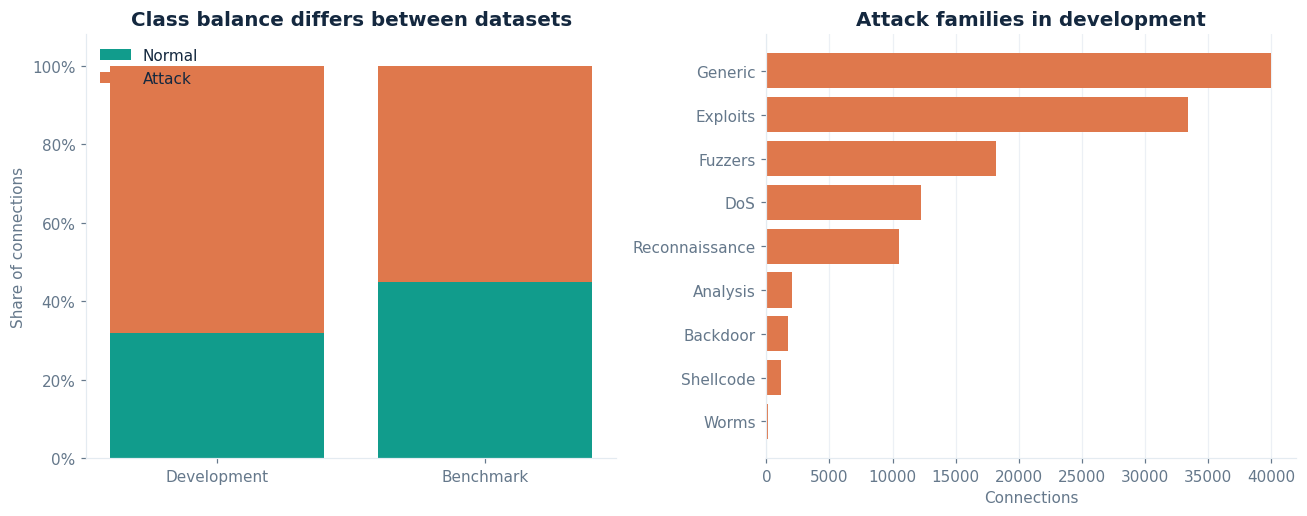

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
names = ["Development", "Benchmark"]
normal = [development.label.eq(0).mean(), benchmark.label.eq(0).mean()]
attack = [development.label.eq(1).mean(), benchmark.label.eq(1).mean()]
axes[0].bar(names, normal, color=COLORS["normal"], label="Normal")
axes[0].bar(names, attack, bottom=normal, color=COLORS["attack"], label="Attack")
axes[0].set(title="Class balance differs between datasets", ylabel="Share of connections", ylim=(0, 1.08))
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].legend(loc="upper left", frameon=False)
counts = development.loc[development.label.eq(1), "attack_cat"].value_counts().sort_values()
axes[1].barh(counts.index.astype(str), counts.values, color=COLORS["attack"])
axes[1].set(title="Attack families in development", xlabel="Connections")
axes[1].grid(axis="x", alpha=.7)
finish_figure(fig, "01_class_balance")

### Measurements and dataset shift

Heavy-tailed byte counts, loads, rates, and duration are displayed with `log1p` on the
horizontal axis. Each histogram is normalized independently by class. Descriptive benchmark
plots help interpret the data; they do not drive fitting, model choice, or threshold tuning.

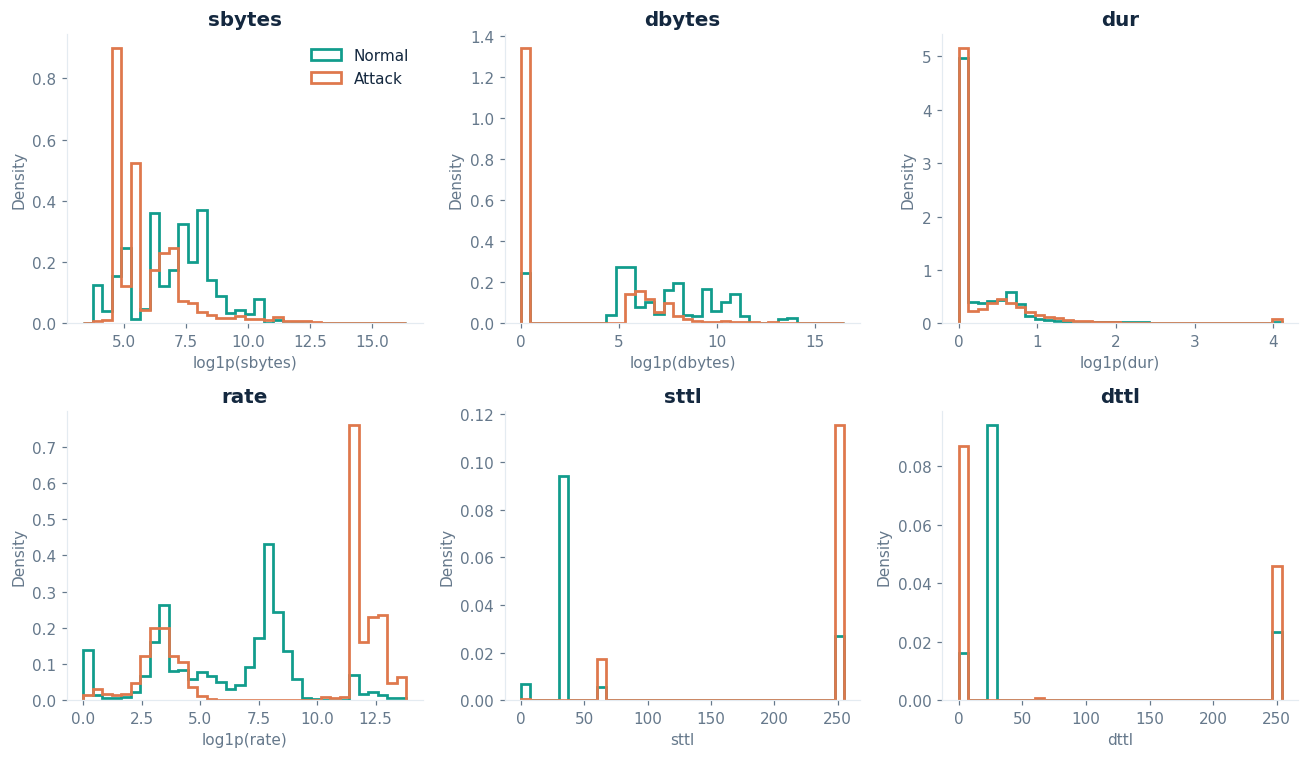

field,development_median,benchmark_median,development_p95,benchmark_p95
sbytes,430.000,534.000,"13,662.000","12,472.000"
dbytes,164.000,178.000,"39,076.000","30,622.000"
spkts,2.000,6.000,64.000,60.000
dpkts,2.000,2.000,62.000,54.000
dur,0.002,0.014,3.080,2.404
rate,"3,225.807","2,650.177","333,333.322","333,333.322"
sload,"879,674.750","577,003.219","266,666,656.000","266,666,656.000"
dload,"1,447.023","2,112.951","4,071,050.000","3,741,445.600"
sttl,254.000,254.000,254.000,254.000
dttl,29.000,29.000,252.000,252.000


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for column, ax in zip(["sbytes", "dbytes", "dur", "rate", "sttl", "dttl"], axes.flat):
    values = development[column].to_numpy(dtype=float)
    logged = column not in ["sttl", "dttl"]
    plotted = np.log1p(values) if logged else values
    bins = np.linspace(plotted.min(), max(plotted.max(), plotted.min()+1), 35)
    for label, caption, color in [(0, "Normal", COLORS["normal"]), (1, "Attack", COLORS["attack"])]:
        ax.hist(plotted[development.label.eq(label)], bins=bins, density=True,
                histtype="step", linewidth=1.8, label=caption, color=color)
    ax.set(title=column, xlabel=f"log1p({column})" if logged else column, ylabel="Density")
axes.flat[0].legend(frameon=False)
finish_figure(fig, "02_measurement_distributions")

shift_rows = []
for column in RAW_INPUTS:
    shift_rows.append({"field": column, "development_median": development[column].median(),
        "benchmark_median": benchmark[column].median(),
        "development_p95": development[column].quantile(.95),
        "benchmark_p95": benchmark[column].quantile(.95)})
show_table(pd.DataFrame(shift_rows))
note("Different class mixtures and measurement distributions can change precision and false alarms even with a frozen threshold.")

<a id="prepare"></a>
## 03 · Prepare without leaking evaluation information

Use one fold of a five-fold stratified group split for validation. Groups are exact signatures
of the ten measured inputs, excluding labels, IDs, and attack names. All matching signatures,
including conflicting labels, stay in one partition. The selected model remains fitted on
the fit partition; it is not refitted after choosing its validation threshold.

`raw measurements → physical features → fitted preprocessing → model → frozen threshold`

Trees use fit-only standardization. MLP and TabM use their own fit-only log and normal-quantile preprocessing.

The CSVs do not provide verified host, capture, or time provenance, so grouping reduces one
specific leakage route without establishing prospective independence.

In [16]:
fit_idx, val_idx, signatures = split_development(development, config)
assert not np.intersect1d(signatures[fit_idx], signatures[val_idx]).size
show_table(pd.DataFrame([
    {"partition": name, "rows": len(idx), "unique_signatures": len(np.unique(signatures[idx])),
     "attack_fraction": development.iloc[idx].label.mean()}
    for name, idx in [("Fit", fit_idx), ("Validation", val_idx)]
]), percent=["attack_fraction"])
note("Confirmed: no measured-input signature crosses the fit and validation partitions.")

partition,rows,unique_signatures,attack_fraction
Fit,144587,65525,70.43%
Validation,30754,16459,56.92%


### Physical feature dictionary

The ten inputs become **29 features** before scaling. Byte and packet totals keep their units.
Bytes per packet divide by the actual packet count. Undefined ratios use a zero sentinel
plus a separate indicator; the sentinel must not be interpreted as a measured zero ratio.
The one-byte-smoothed ratio is explicitly named. Logs use `ln(1 + raw value / one reference unit)`.

For example, 100 source bytes, 50 destination bytes, 4 source packets, and 2 destination packets
give 150 total bytes, 6 packets, 25 bytes per packet in each direction, byte ratio 2,
and signed directional balance 1/3. Low TTL is a candidate predictor, not evidence of an attack.
Raw zero remains zero; negative and nonfinite values fail validation.
Blank cells in the correlation chart mark undefined correlations for features that are constant in the fit partition.


In [17]:
physical_fit = RawTrafficFeatures().transform(development.iloc[fit_idx])
physical_validation = RawTrafficFeatures().transform(development.iloc[val_idx])
physical_checks = {"Development": feature_quality_report(development), "Benchmark": feature_quality_report(benchmark)}
show_table(pd.DataFrame(feature_catalog()))
show_table(pd.DataFrame([
    {"dataset": name, "rows_checked": result["rows"], "checks_passed": all(result["checks"].values()),
     "zero_destination_packet_rows": result["zero_denominator_rows"]["destination_packets"],
     "zero_destination_byte_rows": result["zero_denominator_rows"]["destination_bytes"]}
    for name, result in physical_checks.items()
]))
display(physical_fit.iloc[:3])

feature,meaning,unit,formula,zero_policy
sbytes,Source-to-destination byte count,bytes,measured raw input,Retain recorded zero; never substitute a median.
dbytes,Destination-to-source byte count,bytes,measured raw input,Retain recorded zero; never substitute a median.
spkts,Source-to-destination packet count,packets,measured raw input,Retain recorded zero; never substitute a median.
dpkts,Destination-to-source packet count,packets,measured raw input,Retain recorded zero; never substitute a median.
dur,Recorded connection duration,seconds,measured raw input,Retain recorded zero; never substitute a median.
rate,Connection rate supplied by the dataset; not recomputed,original dataset rate units,measured raw input,Retain recorded zero; never substitute a median.
sload,Recorded source load; not recomputed,original dataset load units,measured raw input,Retain recorded zero; never substitute a median.
dload,Recorded destination load; not recomputed,original dataset load units,measured raw input,Retain recorded zero; never substitute a median.
sttl,Recorded source packet time-to-live value,TTL value,measured raw input,Retain recorded zero; never substitute a median.
dttl,Recorded destination packet time-to-live value,TTL value,measured raw input,Retain recorded zero; never substitute a median.


dataset,rows_checked,checks_passed,zero_destination_packet_rows,zero_destination_byte_rows
Development,175341,True,84282,84282
Benchmark,82332,True,36006,36006


,sbytes,dbytes,spkts,dpkts,dur,rate,...,log1p_sbytes,log1p_dbytes,log1p_dur,log1p_rate,log1p_sload,log1p_dload
0,258.0,172.0,6.0,4.0,0.1215,74.0875,...,5.5568,5.1533,0.1146,4.3187,9.5582,9.0474
1,734.0,42014.0,14.0,38.0,0.6499,78.4734,...,6.5999,10.6458,0.5007,4.3754,9.0355,13.1295
2,364.0,13186.0,8.0,16.0,1.6231,14.1702,...,5.8999,9.4870,0.9644,2.7193,7.3609,11.0175


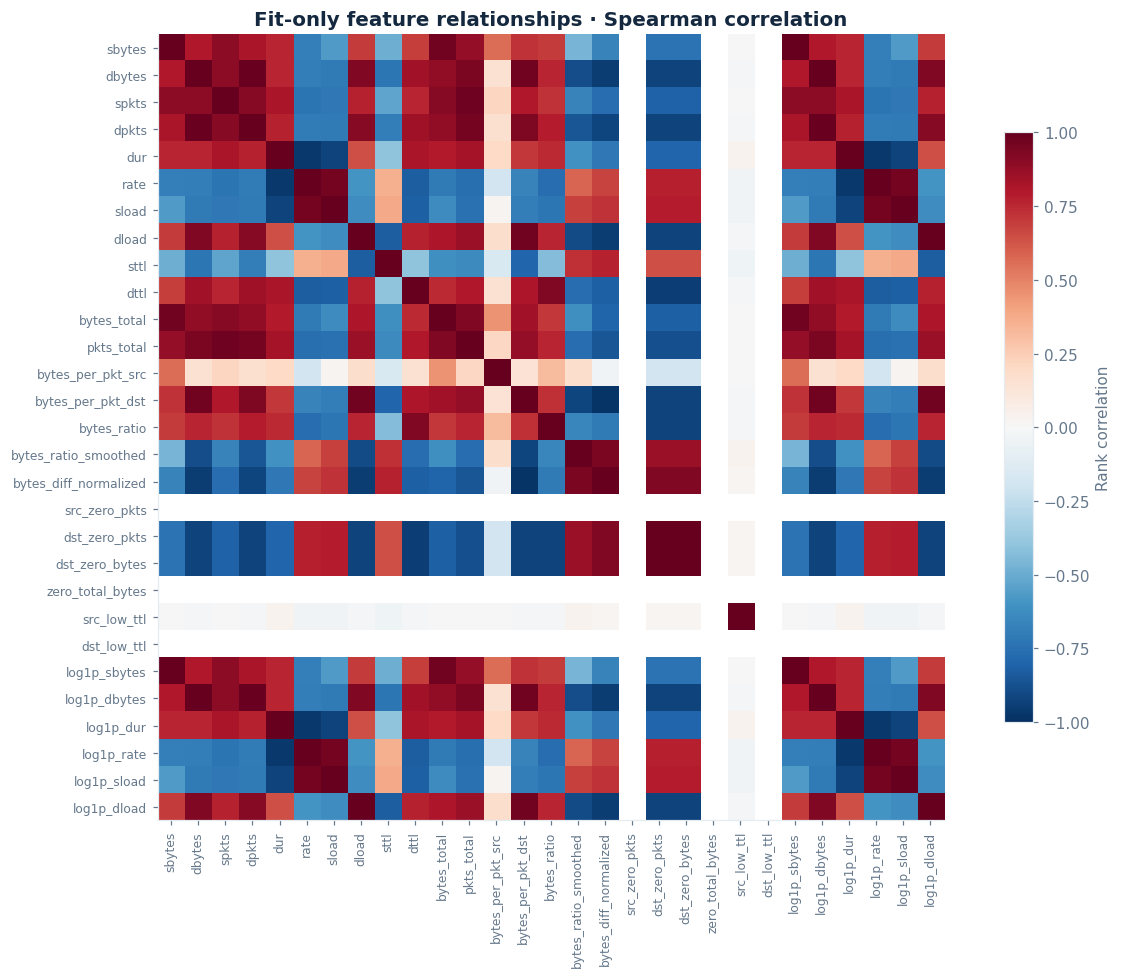

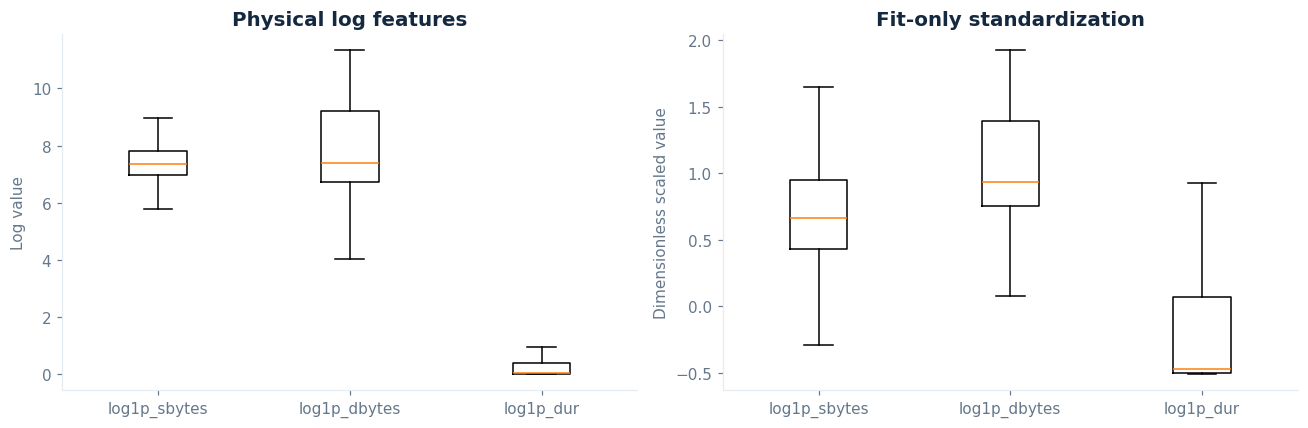

In [18]:
correlation = physical_fit.corr(method="spearman")
fig, ax = plt.subplots(figsize=(12, 9))
image = ax.imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_NAMES)), FEATURE_NAMES, rotation=90, fontsize=8)
ax.set_yticks(range(len(FEATURE_NAMES)), FEATURE_NAMES, fontsize=8)
ax.set_title("Fit-only feature relationships · Spearman correlation")
fig.colorbar(image, ax=ax, shrink=.75, label="Rank correlation")
finish_figure(fig, "03_feature_correlations")

diagnostic_scaler = StandardScaler().fit(physical_fit)
scaled_preview = diagnostic_scaler.transform(physical_fit.iloc[:5000])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
columns = ["log1p_sbytes", "log1p_dbytes", "log1p_dur"]
axes[0].boxplot([physical_fit[c].iloc[:5000] for c in columns], tick_labels=columns, showfliers=False)
axes[0].set(title="Physical log features", ylabel="Log value")
axes[1].boxplot([scaled_preview[:, FEATURE_NAMES.index(c)] for c in columns], tick_labels=columns, showfliers=False)
axes[1].set(title="Fit-only standardization", ylabel="Dimensionless scaled value")
finish_figure(fig, "04_preprocessing")

<a id="supervised"></a>
## 04 · Stronger classifiers and a supervised neural network

The upgraded comparison adds six fixed designs using the same ten measured inputs and 29 physical features:

| New candidate | Declared design | Purpose |
|:--|:--|:--|
| Extra Trees | 400 randomized trees, depth ≤ 24, 80% feature candidates, minimum leaf size 4 | Test a stronger randomized tree baseline |
| XGBoost | 800 histogram boosting rounds, depth 8, learning rate 0.05, regularization | Learn complex interactions with regularized boosted trees |
| CatBoost | 900 symmetric boosting rounds, depth 8, learning rate 0.05, L2=8 | Compare a different boosted-tree design |
| LightGBM | 800 rounds, 63 leaves, depth ≤ 8, learning rate 0.05, minimum leaf rows 40 | Compare histogram boosting with leaf-wise growth |
| TabM | Official TabM, 16 members, two 64-unit blocks, dropout 0.1, AdamW | Compare a parameter-sharing ensemble of neural classifiers |
| Supervised neural network | ReLU layers 64 → 32, Adam, L2 regularization | Learn nonlinear representations directly from labelled connections |

The dummy, logistic regression, random forest, gradient boosting, and previous soft vote remain
reference candidates, so improvement is measured against the exact previous approach.
Trees use the same fit-only StandardScaler. Both neural classifiers use sign-preserving log compression
and their own fit-only normal-quantile transform and scaler. Both learn from attack labels and are separate from the optional reconstruction autoencoder.

**Neural training:** a five-fold grouped split inside the outer fit partition provides an inner monitor.
Only inner-fit rows fit the monitoring quantile transform and scaler. Monitor log loss chooses the best epoch count with patience 15,
within 160 epochs. The network is then initialized again and trained for that fixed number of epochs on all
outer fit rows, with scaling refitted there. The outer validation rows never control neural training duration.
The training history and stopping reason are retained; reaching an epoch cap does not claim optimizer convergence.

**TabM training:** the same inner grouped splitting and fit-only preprocessing rules select its
epoch count, with patience 12 within 80 epochs. The final model is initialized again and refitted
on all outer fit rows. Each of its 16 members receives a separate binary log-loss term;
their sigmoid probabilities are averaged only for prediction and monitoring. It uses the official
`tabm` package, without feature embeddings, and float32 CPU training tensors and converts fitted weights to float64 for final scoring. This is one fixed
architecture comparison rather than a tuned claim about TabM's maximum achievable performance.

For every candidate, choose the maximum validation attack recall at **FPR ≤ 1%**. Tied scores move together.
All hyperparameters and the two new equal-weight votes (Extra Trees + XGBoost + CatBoost;
XGBoost + CatBoost + neural network) are fixed before benchmark scoring. An ensemble is retained only if
it gains at least **2 percentage points** over the best eligible individual and takes no more than **2×**
its median 256-row prediction time. The previous soft vote is also checked against the new best individual.

Candidate ranking is recall, lower FPR, average precision, then name. Optimizer warnings exclude the linear
reference; the new fixed-budget trees and the neural network's selected finite checkpoint are eligible
after successful fitting and finite scoring. The separately reported neural stopping reason avoids conflating
a selected epoch budget with mathematical convergence.

Scores remain uncalibrated classifier outputs. Benchmark traffic is previously inspected and never changes
these thresholds, weights, or model decisions.


In [19]:
bundle, validation_comparison = fit_upgraded_models(development, fit_idx, val_idx, config)
show_table(validation_comparison[["model", "selected", "accuracy", "precision", "recall", "f1",
    "average_precision", "false_positive_rate", "fp", "fn", "candidate_group"]],
    percent=["accuracy", "precision", "recall", "f1", "average_precision", "false_positive_rate"])
show_table(validation_comparison[["model", "fit_seconds", "single_latency_median_ms",
    "batch_latency_median_ms", "artifact_bytes", "optimization_iterations", "optimization_status"]])
cards([
    ("Selected architecture", bundle["model_name"].replace("_", " "), "validation decision"),
    ("Frozen threshold", f"{bundle['threshold']:.6f}", "alert when score ≥ threshold"),
    ("Validation recall", f"{bundle['threshold_selection']['validation_metrics']['recall']:.1%}", "attacks detected"),
    ("Validation false alarms", f"{bundle['threshold_selection']['validation_metrics']['false_positive_rate']:.2%}", "share of normal rows"),
])
show_table(pd.DataFrame(bundle["ensemble_decisions"]).drop(columns="gates"))
previous_recall = bundle["previous_reference"]["validation_metrics"]["recall"]
new_recall = bundle["threshold_selection"]["validation_metrics"]["recall"]
note(f"Change from the previous selected reference: {(new_recall-previous_recall)*100:+.2f} percentage points of validation recall at the same false-alarm budget.")

Fitting candidate: dummy_prior


Fitting candidate: logistic_regression


Fitting candidate: random_forest


Fitting candidate: hist_gradient_boosting


Evaluating candidate: supervised_soft_vote (fixed equal weights)


...

Evaluating upgraded fixed ensemble: advanced_tree_vote


Evaluating upgraded fixed ensemble: tree_neural_vote


model,selected,accuracy,precision,recall,f1,average_precision,false_positive_rate,fp,fn,candidate_group
xgboost,True,88.31%,99.08%,80.22%,88.66%,96.89%,0.99%,131,3463,new candidate
advanced_tree_vote,False,88.22%,99.07%,80.06%,88.55%,98.25%,1.00%,132,3491,new candidate
catboost,False,87.95%,99.06%,79.58%,88.26%,99.02%,1.00%,132,3575,new candidate
tree_neural_vote,False,87.87%,99.06%,79.45%,88.18%,98.87%,1.00%,132,3597,new candidate
supervised_soft_vote,False,87.61%,99.05%,79.00%,87.90%,98.02%,1.00%,132,3677,previous reference
extra_trees,False,86.55%,99.03%,77.13%,86.72%,97.66%,1.00%,132,4004,new candidate
neural_network_mlp,False,85.82%,99.02%,75.84%,85.89%,98.64%,1.00%,132,4230,new candidate
lightgbm,False,85.79%,99.55%,75.38%,85.80%,95.67%,0.45%,59,4310,new candidate
hist_gradient_boosting,False,84.71%,99.67%,73.38%,84.53%,95.31%,0.32%,42,4660,previous reference
random_forest,False,82.81%,98.94%,70.55%,82.37%,98.51%,1.00%,132,5155,previous reference


model,fit_seconds,single_latency_median_ms,batch_latency_median_ms,artifact_bytes,optimization_iterations,optimization_status
xgboost,10.398,34.088,37.255,2986322,800,fixed tree budget
advanced_tree_vote,96.512,66.840,92.626,231263775,0,fixed tree budget
catboost,44.538,32.025,33.471,3796093,900,fixed tree budget
tree_neural_vote,156.753,52.145,59.596,8561506,0,fixed tree budget
supervised_soft_vote,28.869,55.786,68.127,63609112,0,converged
extra_trees,41.576,49.736,67.441,224499000,400,fixed tree budget
neural_network_mlp,101.817,38.184,39.734,1793694,110,inner-monitor patience reached
lightgbm,11.085,39.574,49.976,5185196,800,fixed tree budget
hist_gradient_boosting,3.616,41.768,45.202,599210,150,converged
random_forest,23.147,45.979,55.540,63018675,0,converged


candidate,best_individual,retained,validation_recall_gain,minimum_recall_gain,batch_latency_ratio,maximum_batch_latency_ratio,policy_declared_before_benchmark,interpretation
advanced_tree_vote,xgboost,False,-0.002,0.020,2.486,2.000,True,one grouped validation comparison; not proof of independent generalization
tree_neural_vote,xgboost,False,-0.008,0.020,1.600,2.000,True,one grouped validation comparison; not proof of independent generalization
supervised_soft_vote,xgboost,False,-0.012,0.020,1.829,2.000,True,one grouped validation comparison; not proof of independent generalization


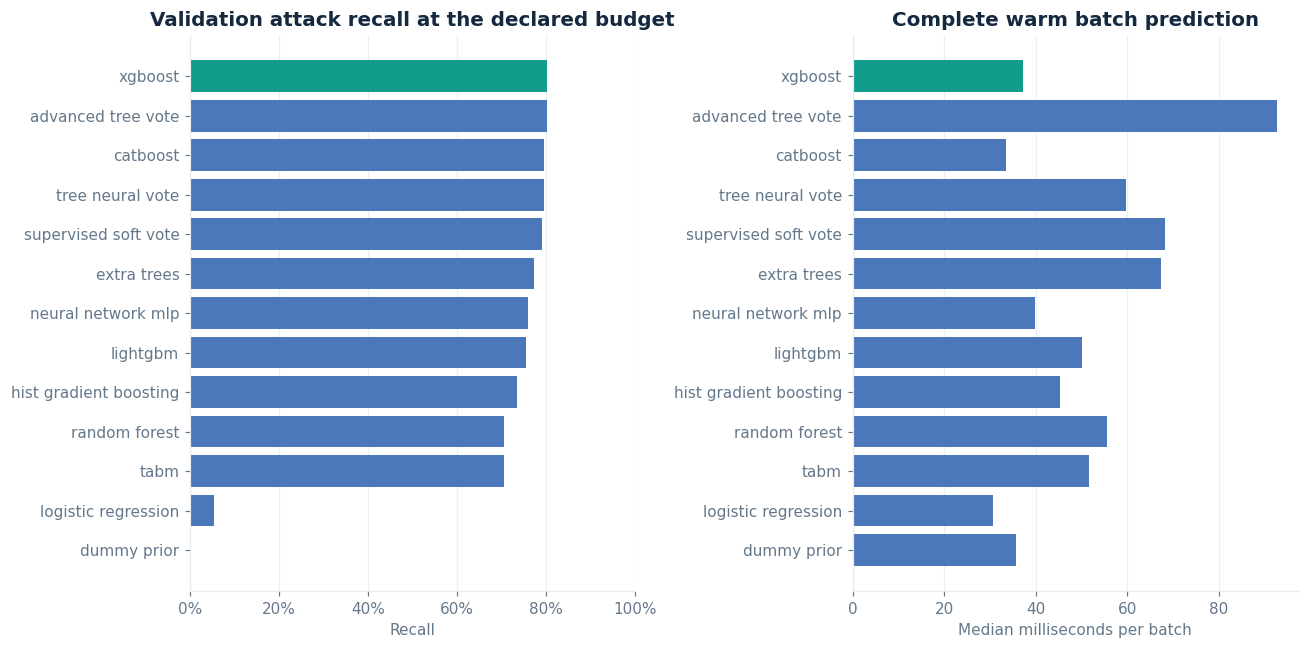

In [20]:
ordered = validation_comparison.sort_values("recall")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
colors = [COLORS["normal"] if selected else COLORS["blue"] for selected in ordered.selected]
axes[0].barh(ordered.model.str.replace("_", " "), ordered.recall, color=colors)
axes[0].set(title="Validation attack recall at the declared budget", xlabel="Recall", xlim=(0, 1))
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].barh(ordered.model.str.replace("_", " "), ordered.batch_latency_median_ms, color=colors)
axes[1].set(title="Complete warm batch prediction", xlabel="Median milliseconds per batch")
for ax in axes: ax.grid(axis="x", alpha=.7)
finish_figure(fig, "05_validation_comparison")
note("Teal marks the selected candidate. Timing varies by machine and may affect the ensemble gate on a new run.")

<a id="anomaly"></a>
## 05 · Neural network learning and optional anomaly references

The new MLP learns from normal and attack labels. It receives all 29 physical features after
sign-preserving log compression, training-fitted normal quantiles, and standardization, followed by hidden layers
64 → 32 and one sigmoid output. Its two probability columns represent normal and attack scores.
The diagram and learning curves below describe the architecture and inner monitoring run.
After epoch selection, the final network is refitted on all outer fit rows.

TabM shares most weights between 16 member networks, with two 64-unit hidden blocks and dropout.
The additional panel reports its inner learning curves, chosen epoch count, and validation score.
Each neural design is refitted using all fitting rows after its epoch count is fixed.


fit_rows,monitor_rows,signature_overlap,monitor_uses_outer_validation
107298,37289,0,False


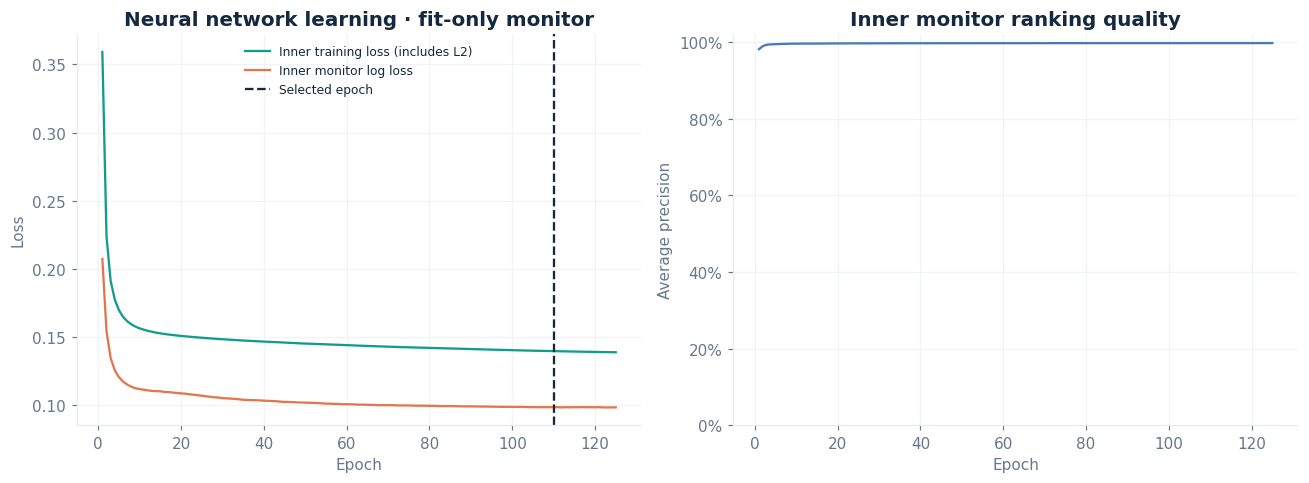

In [21]:
neural_report = bundle["neural_training"]
history = pd.DataFrame(neural_report["history"])
nn_row = validation_comparison.loc[validation_comparison.model.eq("neural_network_mlp")].iloc[0]
cards([
    ("Neural architecture", " → ".join(map(str, [len(FEATURE_NAMES), *neural_report["architecture"], 1])), "ReLU hidden layers; sigmoid output"),
    ("Selected training epochs", neural_report["selected_epochs"], "chosen using inner-monitor log loss"),
    ("Neural validation recall", f"{nn_row.recall:.2%}", "at its frozen validation threshold"),
    ("Neural false alarms", f"{nn_row.false_positive_rate:.2%}", "normal validation rows alerted"),
])
show_table(pd.DataFrame([neural_report["inner_split"]]))
note("Neural stopping reason: " + neural_report["stopping_reason"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history.epoch, history.training_loss, color=COLORS["normal"], label="Inner training loss (includes L2)")
axes[0].plot(history.epoch, history.monitor_log_loss, color=COLORS["attack"], label="Inner monitor log loss")
axes[0].axvline(neural_report["selected_epochs"], color=COLORS["ink"], linestyle="--", label="Selected epoch")
axes[0].set(title="Neural network learning · fit-only monitor", xlabel="Epoch", ylabel="Loss")
axes[0].legend(fontsize=8, frameon=False)
axes[1].plot(history.epoch, history.monitor_average_precision, color=COLORS["blue"])
axes[1].set(title="Inner monitor ranking quality", xlabel="Epoch", ylabel="Average precision", ylim=(0, 1.02))
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
for ax in axes: ax.grid(alpha=.5)
finish_figure(fig, "07_neural_learning")

fit_rows,monitor_rows,signature_overlap,monitor_uses_outer_validation
107298,37289,0,False


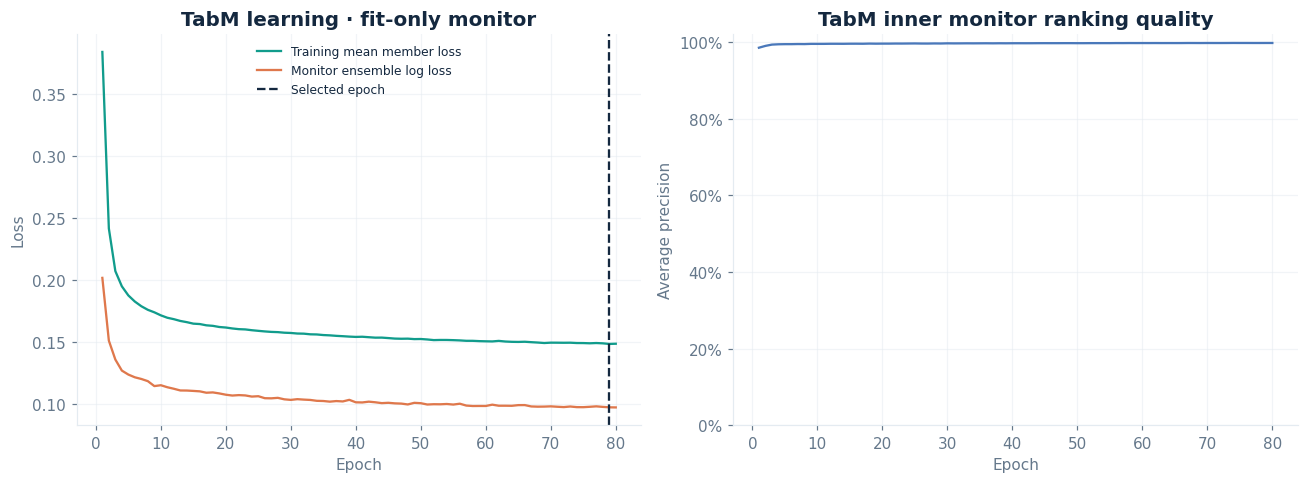

In [22]:
tabm_report = bundle["tabm_training"]
tabm_history = pd.DataFrame(tabm_report["history"])
tabm_row = validation_comparison.loc[validation_comparison.model.eq("tabm")].iloc[0]
lightgbm_row = validation_comparison.loc[validation_comparison.model.eq("lightgbm")].iloc[0]
cards([
    ("LightGBM validation recall", f"{lightgbm_row.recall:.2%}", "800 fixed boosting rounds" if not FAST_RUN else "smoke budget"),
    ("TabM validation recall", f"{tabm_row.recall:.2%}", f"{config.tabm_members} shared-weight neural members"),
    ("TabM selected epochs", tabm_report["selected_epochs"], "chosen entirely inside fitting rows"),
    ("TabM false alarms", f"{tabm_row.false_positive_rate:.2%}", "normal validation rows alerted"),
])
show_table(pd.DataFrame([tabm_report["inner_split"]]))
note("TabM stopping reason: " + tabm_report["stopping_reason"] + "; independent member losses during training; mean probabilities during scoring.")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(tabm_history.epoch, tabm_history.training_loss, color=COLORS["normal"], label="Training mean member loss")
axes[0].plot(tabm_history.epoch, tabm_history.monitor_log_loss, color=COLORS["attack"], label="Monitor ensemble log loss")
axes[0].axvline(tabm_report["selected_epochs"], color=COLORS["ink"], linestyle="--", label="Selected epoch")
axes[0].set(title="TabM learning · fit-only monitor", xlabel="Epoch", ylabel="Loss")
axes[0].legend(fontsize=8, frameon=False)
axes[1].plot(tabm_history.epoch, tabm_history.monitor_average_precision, color=COLORS["blue"])
axes[1].set(title="TabM inner monitor ranking quality", xlabel="Epoch", ylabel="Average precision", ylim=(0, 1.02))
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
for ax in axes: ax.grid(alpha=.5)
finish_figure(fig, "07b_tabm_learning")

### Optional historical anomaly experiments

Enable `RUN_ANOMALY_MODELS` to rerun the prior normal-reference Isolation Forest, novelty LOF,
DBSCAN core-distance scorer, reconstruction autoencoder, and fixed anomaly votes. Their previous
run had low recall under the 1% validation false-alarm budget, so they are optional research references.
`RUN_PROTOCOL_MODEL` additionally enables per-protocol references when `proto` exists.
They sample normal fit rows and use a separately fitted log scaler and PCA projection.
These designs remain separate from the new supervised neural classifier and candidate selection.

In [23]:
class NormalReferenceDetector:
    'A bounded fit-normal reference with a fixed, batch-independent novelty score.'
    def __init__(self, kind, seed=42, limit=3000):
        self.kind, self.seed, self.limit = kind, seed, limit

    @staticmethod
    def compress(frame):
        physical = RawTrafficFeatures().transform(frame)
        return np.log1p(physical.drop(columns="bytes_diff_normalized").to_numpy())

    def fit(self, normal):
        reference = normal.sample(n=min(len(normal), self.limit), random_state=self.seed)
        if len(reference) < 20:
            raise ValueError("Anomaly models need at least 20 normal fit rows.")
        self.scaler_ = StandardScaler().fit(self.compress(reference))
        scaled = self.scaler_.transform(self.compress(reference))
        self.pca_ = PCA(n_components=min(8, scaled.shape[1], len(reference)-1), random_state=self.seed).fit(scaled)
        z = self.pca_.transform(scaled)
        self.reference_rows_ = len(z)
        self.converged_ = True
        self.fit_warnings_ = []
        if self.kind == "isolation_forest":
            self.model_ = IsolationForest(n_estimators=60 if FAST_RUN else 200, contamination="auto",
                                         random_state=self.seed, n_jobs=1).fit(z)
        elif self.kind == "lof":
            self.model_ = LocalOutlierFactor(n_neighbors=min(35, len(z)-1), novelty=True, n_jobs=1).fit(z)
        elif self.kind == "dbscan":
            min_samples = min(10, len(z)-1)
            distances = NearestNeighbors(n_neighbors=min_samples).fit(z).kneighbors(z)[0][:, -1]
            self.eps_ = max(float(np.quantile(distances, .8)), 1e-6)
            self.model_ = DBSCAN(eps=self.eps_, min_samples=min_samples, n_jobs=1).fit(z)
            core = self.model_.components_
            if not len(core):
                raise ValueError("DBSCAN produced no core points; there is no defined novelty scorer.")
            self.neighbors_ = NearestNeighbors(n_neighbors=1).fit(core)
            self.core_points_ = len(core)
        elif self.kind == "autoencoder":
            self.model_ = MLPRegressor(hidden_layer_sizes=(16, 4, 16), activation="tanh", solver="adam",
                max_iter=15 if FAST_RUN else 200, early_stopping=False, random_state=self.seed,
                batch_size=min(128, len(z)), learning_rate_init=.005, tol=1e-4)
            with warnings.catch_warnings(record=True) as caught, threadpool_limits(limits=config.threads):
                warnings.simplefilter("always", ConvergenceWarning)
                self.model_.fit(z, z)
            self.converged_ = not any(issubclass(w.category, ConvergenceWarning) for w in caught)
            self.fit_warnings_ = [str(w.message) for w in caught]
        else:
            raise ValueError(f"Unknown detector: {self.kind}")
        self.reference_scores_ = np.sort(self.raw_scores(reference))
        return self

    def raw_scores(self, frame):
        results = []
        for start in range(0, len(frame), ANOMALY_BATCH_SIZE):
            part = frame.iloc[start:start+ANOMALY_BATCH_SIZE]
            z = self.pca_.transform(self.scaler_.transform(self.compress(part)))
            if self.kind in ("isolation_forest", "lof"):
                raw = -self.model_.score_samples(z)
            elif self.kind == "dbscan":
                raw = self.neighbors_.kneighbors(z)[0][:, 0]
            else:
                raw = np.mean((z-self.model_.predict(z))**2, axis=1)
            results.append(raw)
        return np.concatenate(results)

    def score(self, frame):
        # Fixed reference CDF; never recompute ranks on the prediction batch.
        return np.searchsorted(self.reference_scores_, self.raw_scores(frame), side="right") / len(self.reference_scores_)


class ProtocolIsolationDetector:
    'Fit-only protocol-specific normal references with a global fallback.'
    def fit(self, normal):
        self.fallback_ = NormalReferenceDetector("isolation_forest", config.seed, ANOMALY_FIT_LIMIT).fit(normal)
        self.references_ = {}
        for protocol, part in normal.groupby("proto", sort=True):
            if len(part) >= 100:
                self.references_[str(protocol)] = NormalReferenceDetector(
                    "isolation_forest", config.seed, min(1000, ANOMALY_FIT_LIMIT)).fit(part)
        return self

    def score(self, frame):
        scores = self.fallback_.score(frame)
        for protocol, detector in self.references_.items():
            positions = np.flatnonzero(frame.proto.astype(str).eq(protocol))
            if len(positions):
                scores[positions] = detector.score(frame.iloc[positions])
        return scores

In [24]:
anomaly_detectors, anomaly_thresholds, anomaly_validation_scores = {}, {}, {}
anomaly_rows = []
normal_fit = development.iloc[fit_idx].loc[lambda frame: frame.label.eq(0)]
validation_frame = development.iloc[val_idx]
if RUN_ANOMALY_MODELS:
    for kind in ["isolation_forest", "lof", "dbscan", "autoencoder"]:
        print(f"Fitting normal-reference experiment: {kind}", flush=True)
        started = time.perf_counter()
        detector = NormalReferenceDetector(kind, config.seed, ANOMALY_FIT_LIMIT).fit(normal_fit)
        scores = detector.score(validation_frame)
        threshold = _choose_threshold(validation_frame.label, scores, config.max_false_positive_rate)
        anomaly_detectors[kind], anomaly_thresholds[kind], anomaly_validation_scores[kind] = detector, threshold, scores
        anomaly_rows.append({"model": kind, **score_metrics(validation_frame.label, scores, threshold),
            "fit_reference_rows": detector.reference_rows_, "converged": detector.converged_,
            "experiment_seconds": time.perf_counter()-started})
        if detector.fit_warnings_:
            note(f"{kind}: " + " | ".join(detector.fit_warnings_))
    for name, members in [("if_lof_vote", ["isolation_forest", "lof"]),
                          ("if_lof_autoencoder_vote", ["isolation_forest", "lof", "autoencoder"])]:
        scores = np.mean([anomaly_validation_scores[m] for m in members], axis=0)
        threshold = _choose_threshold(validation_frame.label, scores, config.max_false_positive_rate)
        anomaly_detectors[name] = members
        anomaly_thresholds[name], anomaly_validation_scores[name] = threshold, scores
        anomaly_rows.append({"model": name, **score_metrics(validation_frame.label, scores, threshold),
            "fit_reference_rows": min(anomaly_detectors[m].reference_rows_ for m in members),
            "converged": all(anomaly_detectors[m].converged_ for m in members), "experiment_seconds": 0.0})
    if RUN_PROTOCOL_MODEL and "proto" in development and "proto" in benchmark:
        started = time.perf_counter()
        protocol_detector = ProtocolIsolationDetector().fit(normal_fit)
        scores = protocol_detector.score(validation_frame)
        threshold = _choose_threshold(validation_frame.label, scores, config.max_false_positive_rate)
        anomaly_detectors["protocol_isolation_forest"] = protocol_detector
        anomaly_thresholds["protocol_isolation_forest"] = threshold
        anomaly_validation_scores["protocol_isolation_forest"] = scores
        anomaly_rows.append({"model": "protocol_isolation_forest", **score_metrics(validation_frame.label, scores, threshold),
            "fit_reference_rows": len(normal_fit), "converged": True, "experiment_seconds": time.perf_counter()-started})
        note(f"Protocol experiment fitted {len(protocol_detector.references_)} protocol references; other protocols use the fit-only global fallback. This experiment additionally requires proto.")
    elif RUN_PROTOCOL_MODEL:
        note("Protocol experiment skipped: proto is absent. The ten-field supervised pipeline is fully available.")
    anomaly_comparison = pd.DataFrame(anomaly_rows)
    show_table(anomaly_comparison[["model", "recall", "precision", "f1", "false_positive_rate", "converged", "fit_reference_rows"]],
               percent=["recall", "precision", "f1", "false_positive_rate"])
else:
    anomaly_comparison = pd.DataFrame()
    note("Anomaly experiments are disabled in settings.")

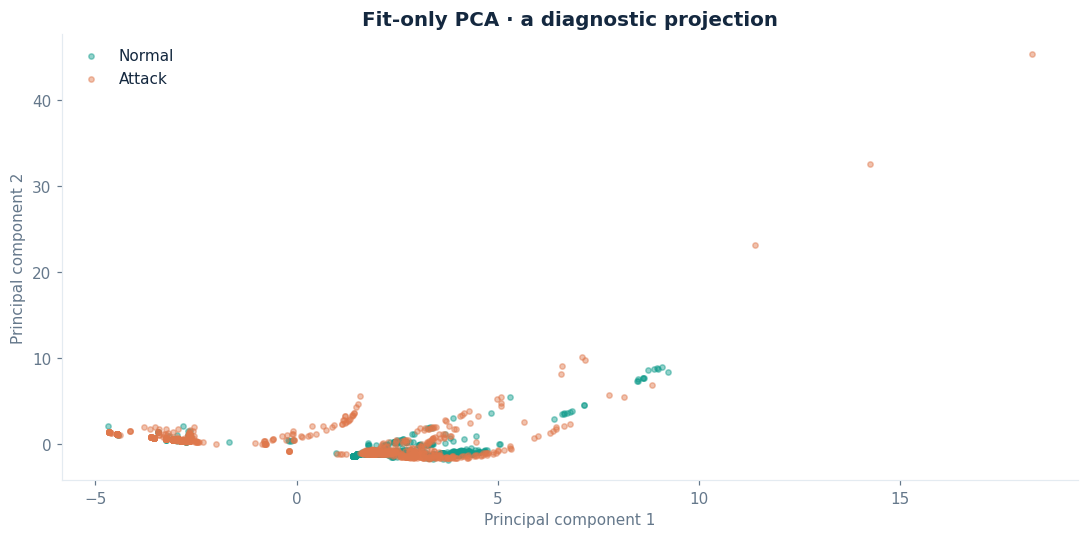

t-SNE is optional and disabled; enable RUN_TSNE for the fit-only diagnostic.


In [25]:
positions = np.sort(rng.choice(len(fit_idx), min(2500, len(fit_idx)), replace=False))
fit_sample = development.iloc[fit_idx[positions]]
pca_display = PCA(n_components=2, random_state=config.seed).fit(diagnostic_scaler.transform(physical_fit))
embedding = pca_display.transform(diagnostic_scaler.transform(RawTrafficFeatures().transform(fit_sample)))
fig, ax = plt.subplots(figsize=(10, 5))
for label, caption, color in [(0, "Normal", COLORS["normal"]), (1, "Attack", COLORS["attack"])]:
    mask = fit_sample.label.eq(label)
    ax.scatter(embedding[mask, 0], embedding[mask, 1], s=12, alpha=.45, color=color, label=caption, rasterized=True)
ax.set(title="Fit-only PCA · a diagnostic projection", xlabel="Principal component 1", ylabel="Principal component 2")
ax.legend(frameon=False)
finish_figure(fig, "06_pca_projection")
note(f"Two PCA components explain {pca_display.explained_variance_ratio_.sum():.1%} of fit feature variance. Visual separation is not a held-out performance measure.")
if RUN_TSNE:
    tsne_sample = fit_sample.iloc[:1500]
    z = diagnostic_scaler.transform(RawTrafficFeatures().transform(tsne_sample))
    projected = TSNE(n_components=2, perplexity=min(30, (len(z)-1)/3), random_state=config.seed, init="pca").fit_transform(z)
    fig, ax = plt.subplots(figsize=(10, 5))
    for label, caption, color in [(0, "Normal", COLORS["normal"]), (1, "Attack", COLORS["attack"])]:
        mask = tsne_sample.label.eq(label)
        ax.scatter(projected[mask, 0], projected[mask, 1], s=12, alpha=.5, color=color, label=caption)
    ax.set(title="Optional fit-only t-SNE · local geometry", xlabel="t-SNE 1", ylabel="t-SNE 2")
    ax.legend(frameon=False)
    finish_figure(fig, "07_tsne_projection")
else:
    print("t-SNE is optional and disabled; enable RUN_TSNE for the fit-only diagnostic.")

<a id="evaluate"></a>
## 06 · Evaluate frozen decisions

Benchmark evaluation starts after every fit and validation threshold has been fixed.
An alert is `score ≥ threshold`. A false positive is a normal row alerted; a false negative
is an attack row missed. Recall measures detected attacks; FPR measures false alarms among normals.
Precision and PR summaries depend on the dataset's attack prevalence.

The comparison reports all experiments, but the chosen supervised architecture remains the
validation selection. Benchmark scores do not choose a new winner or move a threshold.

In [26]:
predictions, benchmark_metrics, slice_metrics, category_metrics = evaluate_benchmark(bundle, benchmark, development)
benchmark_scores = {name: predict_raw(candidate, benchmark).attack_score.to_numpy()
                    for name, candidate in bundle["_comparison_candidates"].items()}
comparison_rows = list(bundle["benchmark_comparison"])
for name, detector in anomaly_detectors.items():
    if isinstance(detector, list):
        scores = np.mean([benchmark_scores[m] for m in detector], axis=0)
    else:
        scores = detector.score(benchmark)
    benchmark_scores[name] = scores
    comparison_rows.append({"model": name, **score_metrics(benchmark.label, scores, anomaly_thresholds[name]), "selected": False})
all_benchmark_comparison = pd.DataFrame(comparison_rows)
show_table(all_benchmark_comparison[["model", "selected", "accuracy", "precision", "recall", "f1",
    "average_precision", "false_positive_rate", "fp", "fn"]],
    percent=["accuracy", "precision", "recall", "f1", "average_precision", "false_positive_rate"])
cards([
    ("Benchmark recall", f"{benchmark_metrics['recall']:.1%}", "selected supervised model"),
    ("Benchmark precision", f"{benchmark_metrics['precision']:.1%}", "alerts that are attacks"),
    ("False-positive rate", f"{benchmark_metrics['false_positive_rate']:.2%}", "normal rows alerted"),
    ("Missed attacks", f"{benchmark_metrics['fn']:,}", "false negatives at the frozen threshold"),
])

model,selected,accuracy,precision,recall,f1,average_precision,false_positive_rate,fp,fn
dummy_prior,False,44.94%,0.00%,0.00%,0.00%,55.06%,0.00%,0,45332
logistic_regression,False,49.04%,74.30%,11.40%,19.76%,83.71%,4.83%,1787,40166
random_forest,False,90.31%,97.36%,84.69%,90.59%,98.29%,2.81%,1039,6941
hist_gradient_boosting,False,90.56%,99.35%,83.41%,90.68%,98.22%,0.67%,248,7521
supervised_soft_vote,False,91.24%,97.28%,86.51%,91.58%,98.26%,2.96%,1095,6114
extra_trees,False,90.96%,97.27%,85.99%,91.28%,98.23%,2.96%,1096,6349
xgboost,True,91.69%,97.36%,87.27%,92.04%,98.31%,2.89%,1071,5771
catboost,False,91.72%,97.49%,87.20%,92.06%,98.54%,2.75%,1016,5802
neural_network_mlp,False,90.30%,97.32%,84.71%,90.58%,97.99%,2.85%,1056,6931
lightgbm,False,90.65%,98.81%,84.04%,90.83%,98.22%,1.24%,459,7235


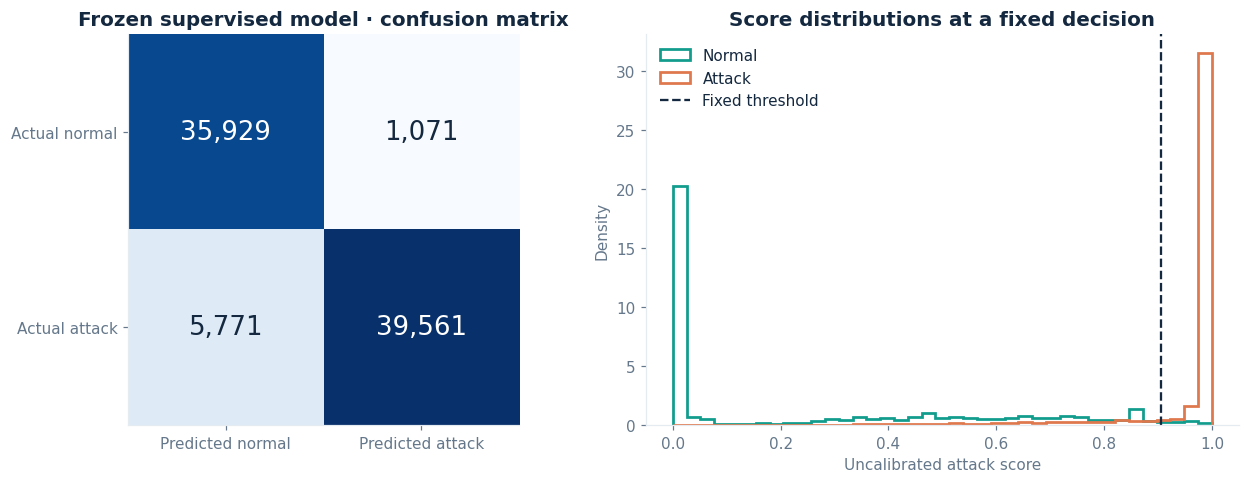

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
matrix = np.array([[benchmark_metrics["tn"], benchmark_metrics["fp"]],
                   [benchmark_metrics["fn"], benchmark_metrics["tp"]]])
axes[0].imshow(matrix, cmap="Blues")
axes[0].set_xticks([0, 1], ["Predicted normal", "Predicted attack"])
axes[0].set_yticks([0, 1], ["Actual normal", "Actual attack"])
axes[0].set_title("Frozen supervised model · confusion matrix")
for row in range(2):
    for col in range(2):
        axes[0].text(col, row, f"{matrix[row,col]:,}", ha="center", va="center", fontsize=17,
                     color="white" if matrix[row,col] > matrix.max()/2 else COLORS["ink"])
for label, caption, color in [(0, "Normal", COLORS["normal"]), (1, "Attack", COLORS["attack"])]:
    axes[1].hist(predictions.loc[predictions.true_label.eq(label), "attack_score"], bins=np.linspace(0,1,40),
                 density=True, histtype="step", linewidth=1.8, color=color, label=caption)
axes[1].axvline(bundle["threshold"], color=COLORS["ink"], linestyle="--", label="Fixed threshold")
axes[1].set(title="Score distributions at a fixed decision", xlabel="Uncalibrated attack score", ylabel="Density")
axes[1].legend(frameon=False)
finish_figure(fig, "08_confusion_and_scores")

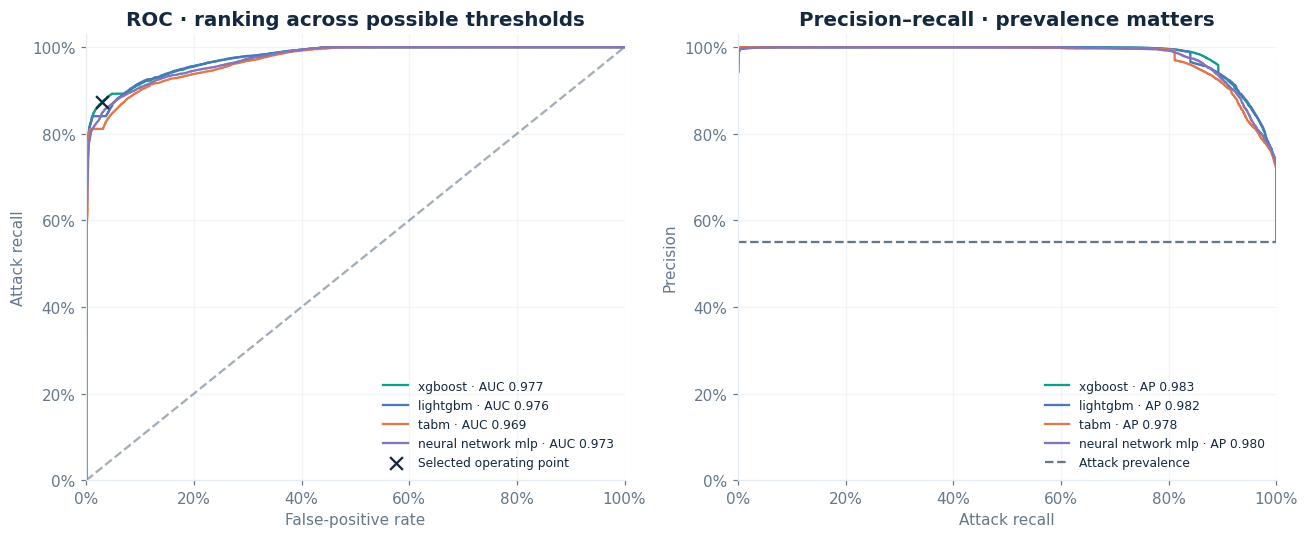

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
palette = [COLORS[k] for k in ["normal", "blue", "attack", "purple", "muted"]]
curve_names = [bundle["model_name"], "xgboost", "lightgbm", "tabm", "neural_network_mlp"]
for name, color in zip(dict.fromkeys(curve_names), palette):
    if name not in benchmark_scores:
        continue
    scores = benchmark_scores[name]
    fpr, tpr, _ = roc_curve(benchmark.label, scores)
    precision, recall, _ = precision_recall_curve(benchmark.label, scores)
    summary = all_benchmark_comparison.loc[all_benchmark_comparison.model.eq(name)].iloc[0]
    axes[0].plot(fpr, tpr, color=color, label=f"{name.replace('_',' ')} · AUC {summary.roc_auc:.3f}")
    axes[1].plot(recall, precision, color=color, label=f"{name.replace('_',' ')} · AP {summary.average_precision:.3f}")
axes[0].plot([0,1], [0,1], linestyle="--", color=COLORS["muted"], alpha=.6)
axes[0].scatter([benchmark_metrics["false_positive_rate"]], [benchmark_metrics["recall"]],
                s=70, color=COLORS["ink"], marker="x", zorder=5, label="Selected operating point")
axes[1].axhline(benchmark.label.mean(), color=COLORS["muted"], linestyle="--", label="Attack prevalence")
axes[0].set(title="ROC · ranking across possible thresholds", xlabel="False-positive rate", ylabel="Attack recall")
axes[1].set(title="Precision–recall · prevalence matters", xlabel="Attack recall", ylabel="Precision")
for ax in axes:
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.03)
    ax.xaxis.set_major_formatter(PercentFormatter(1)); ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(alpha=.5); ax.legend(fontsize=8, loc="lower right", frameon=False)
finish_figure(fig, "09_roc_precision_recall")

partition,target_fpr,observed_fpr,attack_recall,false_positives,normal_rows
Validation,1.00%,0.99%,80.22%,131,13248
Benchmark,1.00%,2.89%,87.27%,1071,37000


attack_category,rows,attack_rows,attack_recall,alert_rate
Analysis,677,677,91.43%,91.43%
Backdoor,583,583,98.11%,98.11%
DoS,4089,4089,91.54%,91.54%
Exploits,11132,11132,90.59%,90.59%
Fuzzers,6062,6062,39.44%,39.44%
Generic,18871,18871,99.11%,99.11%
Normal,37000,0,—,2.89%
Reconnaissance,3496,3496,93.79%,93.79%
Shellcode,378,378,36.51%,36.51%
Worms,44,44,72.73%,72.73%


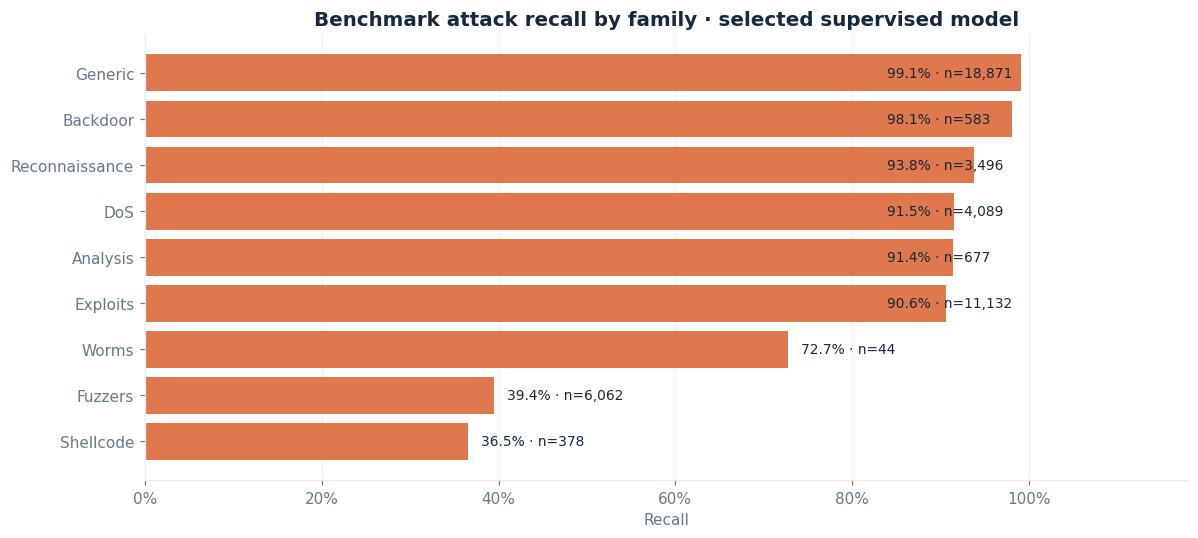

In [29]:
validation_point = bundle["threshold_selection"]["validation_metrics"]
show_table(pd.DataFrame([
    {"partition": name, "target_fpr": config.max_false_positive_rate, "observed_fpr": values["false_positive_rate"],
     "attack_recall": values["recall"], "false_positives": values["fp"], "normal_rows": values["tn"]+values["fp"]}
    for name, values in [("Validation", validation_point), ("Benchmark", benchmark_metrics)]
]), percent=["target_fpr", "observed_fpr", "attack_recall"])
attack_categories = category_metrics.loc[category_metrics.attack_rows.gt(0)].sort_values("attack_recall")
show_table(category_metrics, percent=["attack_recall", "alert_rate"])
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(attack_categories.attack_category, attack_categories.attack_recall, color=COLORS["attack"])
for y, row in enumerate(attack_categories.itertuples()):
    ax.text(min(row.attack_recall+.015, .84), y, f"{row.attack_recall:.1%} · n={row.attack_rows:,}", va="center", fontsize=9)
ax.set(title="Benchmark attack recall by family · selected supervised model", xlabel="Recall", xlim=(0, 1.18))
ax.xaxis.set_major_formatter(PercentFormatter(1)); ax.grid(axis="x", alpha=.6)
finish_figure(fig, "10_attack_family_recall")

<a id="robustness"></a>
## 07 · Robustness and uncertainty

Separate signatures seen in actual **fit rows** from those unseen in fit and unseen anywhere
in development. These slices have different class mixtures, so differences are descriptive.
Intervals resample whole measured-input signatures, preserving repeated and conflicting-label rows.
They describe uncertainty within these CSVs, not new hosts, captures, or model selection.

The default 100 signature-cluster bootstrap repetitions keep the notebook practical; use 400 or
more for a report requiring more stable interval estimates. Small category samples and boundary
estimates can produce degenerate intervals, so their counts and uncertainty flags are retained.

In [30]:
fit_seen = seen_signatures(benchmark, development.iloc[fit_idx])
development_seen = seen_signatures(benchmark, development)
scope_masks = {
    "All benchmark": np.ones(len(benchmark), dtype=bool),
    "Seen in fit": fit_seen,
    "Unseen in fit": ~fit_seen,
    "Unseen anywhere in development": ~development_seen,
}
robustness_rows, robustness_category_rows = [], []
for scope, mask in scope_masks.items():
    if mask.any():
        overall, categories = evaluate_frame(benchmark.loc[mask], predictions.attack_score.to_numpy()[mask],
            bundle["threshold"], scope=scope, repeats=BOOTSTRAP_REPEATS, seed=config.seed,
            categories=(scope == "All benchmark"))
        robustness_rows.append(overall)
        robustness_category_rows.extend(categories)
robustness = pd.DataFrame(robustness_rows)
show_table(robustness[["scope", "rows", "normal_rows", "attack_rows", "unique_signatures", "precision", "recall", "f1", "false_positive_rate"]],
           percent=["precision", "recall", "f1", "false_positive_rate"])
show_table(robustness[["scope", "recall", "recall_ci_low", "recall_ci_high",
                       "false_positive_rate", "false_positive_rate_ci_low", "false_positive_rate_ci_high", "uncertainty_flags"]],
           percent=["recall", "recall_ci_low", "recall_ci_high", "false_positive_rate", "false_positive_rate_ci_low", "false_positive_rate_ci_high"])
show_table(pd.DataFrame(robustness_category_rows)[["attack_category", "attack_rows", "attack_signatures", "recall",
    "recall_ci_low", "recall_ci_high", "uncertainty_flags"]], percent=["recall", "recall_ci_low", "recall_ci_high"])

scope,rows,normal_rows,attack_rows,unique_signatures,precision,recall,f1,false_positive_rate
All benchmark,82332,37000,45332,43336,97.36%,87.27%,92.04%,2.89%
Seen in fit,30691,6299,24392,1632,99.67%,97.31%,98.48%,1.25%
Unseen in fit,51641,30701,20940,41704,94.10%,75.57%,83.82%,3.23%
Unseen anywhere in development,46814,28217,18597,41306,93.36%,73.62%,82.32%,3.45%


scope,recall,recall_ci_low,recall_ci_high,false_positive_rate,false_positive_rate_ci_low,false_positive_rate_ci_high,uncertainty_flags
All benchmark,87.27%,81.94%,89.49%,2.89%,2.61%,3.18%,
Seen in fit,97.31%,95.09%,98.45%,1.25%,0.85%,1.85%,
Unseen in fit,75.57%,73.34%,78.08%,3.23%,2.89%,3.56%,
Unseen anywhere in development,73.62%,72.34%,74.83%,3.45%,3.22%,3.68%,


attack_category,attack_rows,attack_signatures,recall,recall_ci_low,recall_ci_high,uncertainty_flags
Analysis,677,149,91.43%,85.80%,94.66%,
Backdoor,583,163,98.11%,96.68%,99.05%,
DoS,4089,1339,91.54%,87.73%,94.43%,
Exploits,11132,7214,90.59%,89.12%,91.88%,
Fuzzers,6062,4028,39.44%,34.58%,43.56%,
Generic,18871,707,99.11%,97.91%,99.46%,
Reconnaissance,3496,1970,93.79%,92.09%,95.13%,
Shellcode,378,370,36.51%,32.73%,41.56%,
Worms,44,44,72.73%,59.18%,83.51%,


### Optional: stronger splits and withheld attack families

Enable `RUN_EXTENDED_GENERALIZATION` to refit the already selected architecture on three
signature-disjoint fit/calibration/evaluation splits (seeds 42, 43, 44), then withhold each
attack family in turn. The calibration partition selects the threshold; evaluation never does.
Withheld-family signatures, including other rows with the same measurements, are excluded from
fit and calibration. A fixed architecture is refitted; this section performs no new model search.

These additional fits can take substantially longer than the main report. Their artifacts and
memberships are saved separately and never replace the selected notebook model.

In [31]:
extended_rows = []
if RUN_EXTENDED_GENERALIZATION:
    experiments = [(f"Grouped seed {seed}", seed, None) for seed in (42, 43, 44)]
    experiments += [(f"Withheld {family}", config.seed, str(family))
                    for family in sorted(development.loc[development.label.eq(1), "attack_cat"].unique())]
    for index, (name, seed, family) in enumerate(experiments):
        print(f"Robustness refit: {name}", flush=True)
        fit, calibration, evaluation, partition = three_way_partition(
            development, seed=seed, folds=config.validation_folds, held_family=family)
        experiment_bundle, fit_report = fit_frozen_design(bundle, development, fit, calibration, config)
        scores = predict_raw(experiment_bundle, development.iloc[evaluation]).attack_score.to_numpy()
        overall, categories = evaluate_frame(development.iloc[evaluation], scores, experiment_bundle["threshold"],
            scope=name, repeats=BOOTSTRAP_REPEATS, seed=seed, categories=False)
        extended_rows.append({**overall, **partition, "converged": fit_report["converged"], "fit_seconds": fit_report["fit_seconds"]})
        partition_membership(development, fit, calibration, evaluation, held_family=family).to_csv(
            OUTPUT/f"extended_partition_{index:02d}.csv", index=False)
        pd.DataFrame({"row_id": development.iloc[evaluation].id, "true_label": development.iloc[evaluation].label,
            "attack_score": scores, "predicted_label": (scores >= experiment_bundle["threshold"]).astype(int)}).to_csv(
            OUTPUT/f"extended_predictions_{index:02d}.csv", index=False)
    show_table(pd.DataFrame(extended_rows)[["scope", "rows", "recall", "precision", "f1", "false_positive_rate", "converged"]],
               percent=["recall", "precision", "f1", "false_positive_rate"])
else:
    note("Extended refits are disabled. Enable RUN_EXTENDED_GENERALIZATION in settings to run all three grouped splits and every withheld-family experiment.")

<a id="export"></a>
## 08 · Portable predictions and exports

The selected pipeline includes physical feature creation, fitted scaling, the classifier,
and its fixed threshold. Save notebook-defined classes with cloudpickle so the model can be
reloaded in a fresh Python process without this project's helper modules.
Load only your own trusted model files: Python model serialization can execute code.

Outputs are research artifacts inside the chosen output folder. The application uses its
existing separately managed serving artifact. The notebook export has its own feature-code
fingerprints and is named `netguard_model.pkl`. The MLP, LightGBM, and TabM candidates
are also exported as `neural_network_model.pkl`, `lightgbm_model.pkl`, and `tabm_model.pkl`,
even when they are not selected. Each export is checked for reload and batch consistency.

Reload verification compares a saved batch with its original scores and individual-row predictions
at float64 precision. Invalid or incomplete measurements raise clear exceptions.

In [32]:
model_bundle = {key: value for key, value in bundle.items() if key != "_comparison_candidates"}
model_bundle["benchmark_metrics"] = benchmark_metrics
MODEL_PATH = OUTPUT/"netguard_model.pkl"
additional_exports = {"neural_network_mlp": "neural_network_model.pkl",
                      "lightgbm": "lightgbm_model.pkl", "tabm": "tabm_model.pkl"}
additional_export_checks = {}
for name, filename in additional_exports.items():
    candidate = bundle["_comparison_candidates"][name]
    with (OUTPUT/filename).open("wb") as handle:
        cloudpickle.dump(candidate, handle, protocol=5)
    with (OUTPUT/filename).open("rb") as handle:
        reloaded = cloudpickle.load(handle)
    export_sample = benchmark.loc[:, list(RAW_INPUTS)].iloc[:16]
    original = predict_raw(candidate, export_sample)
    reloaded_batch = predict_raw(reloaded, export_sample)
    reloaded_single = pd.concat([predict_raw(reloaded, export_sample.iloc[[i]]) for i in range(len(export_sample))])
    np.testing.assert_allclose(original.attack_score, reloaded_batch.attack_score, rtol=0, atol=1e-12)
    np.testing.assert_allclose(reloaded_batch.attack_score, reloaded_single.attack_score, rtol=0, atol=1e-12)
    np.testing.assert_array_equal(reloaded_batch.predicted_label, reloaded_single.predicted_label)
    additional_export_checks[name] = {"reload_matches": True, "single_and_batch_match": True}
with MODEL_PATH.open("wb") as handle:
    cloudpickle.dump(model_bundle, handle, protocol=5)
with MODEL_PATH.open("rb") as handle:
    restored_bundle = cloudpickle.load(handle)
sample = benchmark.loc[:, list(RAW_INPUTS)].iloc[:16]
expected = predict_raw(bundle, sample)
restored = predict_raw(restored_bundle, sample)
singles = pd.concat([predict_raw(restored_bundle, sample.iloc[[i]]) for i in range(len(sample))])
np.testing.assert_allclose(expected.attack_score, restored.attack_score, rtol=0, atol=1e-12)
np.testing.assert_allclose(restored.attack_score, singles.attack_score, rtol=0, atol=1e-12)
np.testing.assert_array_equal(restored.predicted_label, singles.predicted_label)

tables = {
    "benchmark_predictions.csv": predictions, "validation_comparison.csv": validation_comparison,
    "benchmark_comparison.csv": all_benchmark_comparison, "attack_category_metrics.csv": category_metrics,
    "signature_slices.csv": robustness, "category_uncertainty.csv": pd.DataFrame(robustness_category_rows),
    "feature_dictionary.csv": pd.DataFrame(feature_catalog()),
    "neural_training_history.csv": pd.DataFrame(bundle["neural_training"]["history"]),
    "tabm_training_history.csv": pd.DataFrame(bundle["tabm_training"]["history"]),
}
if len(anomaly_comparison): tables["anomaly_validation_comparison.csv"] = anomaly_comparison
if extended_rows: tables["extended_generalization.csv"] = pd.DataFrame(extended_rows)
split_membership = pd.DataFrame({"row_id": development.id, "signature": signatures, "partition": "fit"})
split_membership.iloc[val_idx, split_membership.columns.get_loc("partition")] = "validation"
tables["development_split.csv"] = split_membership
for name, frame in tables.items():
    frame.to_csv(OUTPUT/name, index=False, float_format="%.17g")
(OUTPUT/"feature_quality.json").write_text(json.dumps(physical_checks, indent=2), encoding="utf-8")
metrics_summary = {"selected_model": bundle["model_name"], "threshold": bundle["threshold"],
    "validation": validation_point, "benchmark": benchmark_metrics,
    "ensemble_decision": bundle["ensemble_decision"], "score_calibration": bundle["score_calibration"],
    "previous_reference": bundle["previous_reference"],
    "neural_training": {k: v for k, v in bundle["neural_training"].items() if k != "history"},
    "tabm_training": {k: v for k, v in bundle["tabm_training"].items() if k != "history"},
    "evaluation_status": bundle["evaluation_status"]}
(OUTPUT/"metrics.json").write_text(json.dumps(metrics_summary, indent=2, allow_nan=False), encoding="utf-8")
manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(), "python": platform.python_version(),
    "packages": {name: version(name) for name in EXPECTED_VERSIONS}, "configuration": asdict(config),
    "fast_run": FAST_RUN, "bootstrap_repeats": BOOTSTRAP_REPEATS,
    "selected_model": bundle["model_name"], "threshold": bundle["threshold"],
    "raw_inputs": list(RAW_INPUTS), "feature_names": list(FEATURE_NAMES),
    "fit_rows": len(fit_idx), "validation_rows": len(val_idx), "benchmark_rows": len(benchmark),
    "evaluation_status": bundle["evaluation_status"],
    "input_sha256": {name: file_sha256(DATA/name) for name in [training_name, testing_name]},
    "model_sha256": file_sha256(MODEL_PATH),
    "feature_implementation_sha256": FEATURE_IMPLEMENTATION_SHA,
    "model_implementation_sha256": MODEL_IMPLEMENTATION_SHA,
    "new_models": ["extra_trees", "xgboost", "catboost", "neural_network_mlp", "lightgbm", "tabm"],
    "neural_model_sha256": file_sha256(OUTPUT/"neural_network_model.pkl"),
    "additional_models": {name: {"file": filename, "sha256": file_sha256(OUTPUT/filename),
        "checks": additional_export_checks[name]} for name, filename in additional_exports.items()},
    "checks": {"grouped_split_disjoint": True, "physical_features_verified": True,
               "artifact_reload_matches": True, "single_and_batch_match": True},
    "optional_runs": {"tsne": RUN_TSNE, "extended_generalization": RUN_EXTENDED_GENERALIZATION,
                      "anomaly_models": RUN_ANOMALY_MODELS},
}
(OUTPUT/"manifest.json").write_text(json.dumps(manifest, indent=2, allow_nan=False), encoding="utf-8")
note("Passed: saved model reload, original versus restored scores, and single versus batch predictions agree.")
show_table(pd.DataFrame([{"file": p.name, "size_kb": p.stat().st_size/1024}
                         for p in sorted(OUTPUT.iterdir()) if p.is_file() and p.suffix in [".pkl", ".csv", ".json"]]))

file,size_kb
anomaly_validation_comparison.csv,1.579
attack_category_metrics.csv,0.613
benchmark_comparison.csv,3.674
benchmark_predictions.csv,"3,601.033"
category_uncertainty.csv,5.535
development_split.csv,"5,671.337"
execution_check.json,0.497
feature_dictionary.csv,4.655
feature_quality.json,2.607
lightgbm_model.pkl,"5,074.408"


In [33]:
# Replace these measured values with your own connection. Missing fields are rejected.
new_connection = benchmark.loc[:, list(RAW_INPUTS)].iloc[[0]].copy()
display(new_connection)
prediction = predict_raw(restored_bundle, new_connection)
display(prediction)
decision = "Attack alert" if int(prediction.predicted_label.iloc[0]) else "Normal decision"
cards([(decision, f"{prediction.attack_score.iloc[0]:.6f}", f"fixed threshold {bundle['threshold']:.6f}")])

# Standalone reload recipe: package imports + this saved file; no project modules required.
display(Markdown('''```python
import cloudpickle
import pandas as pd

with open("netguard_model.pkl", "rb") as handle:
    saved = cloudpickle.load(handle)
scores = saved["pipeline"].predict_proba(raw_connections)[:, 1]
labels = (scores >= saved["threshold"]).astype(int)
```'''))

,sbytes,dbytes,spkts,dpkts,dur,rate,sload,dload,sttl,dttl
0,496,0,2,0,1.1000e-05,90909.0902,1.8036e+08,0.0,254,0


,attack_score,predicted_label
0,0.8587,0


```python
import cloudpickle
import pandas as pd

with open("netguard_model.pkl", "rb") as handle:
    saved = cloudpickle.load(handle)
scores = saved["pipeline"].predict_proba(raw_connections)[:, 1]
labels = (scores >= saved["threshold"]).astype(int)
```

<a id="conclusions"></a>
## 09 · Findings and next steps

The summary below is generated from this run rather than copied from an earlier notebook.
Use the measured false-positive rate and attack-family recall alongside overall F1.

In [34]:
selected = bundle["model_name"].replace("_", " ")
budget_status = "meets" if benchmark_metrics["false_positive_rate"] <= config.max_false_positive_rate else "exceeds"
weakest = attack_categories.iloc[0]
display(Markdown(
    f"**Selected model:** {selected}, chosen on grouped validation. At the frozen threshold "
    f"`{bundle['threshold']:.8f}`, benchmark recall is **{benchmark_metrics['recall']:.2%}**, "
    f"precision is **{benchmark_metrics['precision']:.2%}**, and F1 is **{benchmark_metrics['f1']:.4f}**.\n\n"
    f"The benchmark false-positive rate is **{benchmark_metrics['false_positive_rate']:.2%}** "
    f"({benchmark_metrics['fp']:,} false alarms among {benchmark_metrics['tn']+benchmark_metrics['fp']:,} "
    f"normal connections), which **{budget_status}** the {config.max_false_positive_rate:.0%} validation budget. "
    f"The weakest benchmark family by point recall is **{weakest.attack_category}** "
    f"(**{weakest.attack_recall:.1%}**, {int(weakest.attack_rows):,} attacks).\n\n"
    "These are measured results on previously inspected data. Signature grouping and bootstrap intervals "
    "do not establish new-host, new-capture, or future-traffic performance. A prospective holdout with "
    "verified capture provenance is the next evaluation step."
))
neural_validation = validation_comparison.loc[validation_comparison.model.eq("neural_network_mlp")].iloc[0]
neural_benchmark = all_benchmark_comparison.loc[all_benchmark_comparison.model.eq("neural_network_mlp")].iloc[0]
display(Markdown(
    f"**Measured upgrade:** validation recall changed from **{previous_recall:.2%}** for the previous selected reference "
    f"to **{new_recall:.2%}** for this run's selected candidate, a change of **{(new_recall-previous_recall)*100:+.2f} percentage points**.\n\n"
    f"**Supervised neural network:** validation recall **{neural_validation.recall:.2%}** and benchmark recall "
    f"**{neural_benchmark.recall:.2%}**, with benchmark false-positive rate **{neural_benchmark.false_positive_rate:.2%}**. "
    f"Its epoch count was selected entirely inside the fitting partition."
))

new_comparison = validation_comparison.loc[validation_comparison.model.isin(["xgboost", "lightgbm", "tabm"])]
display(Markdown("**Requested LightGBM / TabM comparison:** all three use the same fit/validation split and a validation-selected threshold under the 1% false-alarm budget. The benchmark remains previously inspected."))
show_table(new_comparison[["model", "selected", "recall", "false_positive_rate", "f1", "batch_latency_median_ms"]],
           percent=["recall", "false_positive_rate", "f1"])


**Selected model:** xgboost, chosen on grouped validation. At the frozen threshold `0.90511036`, benchmark recall is **87.27%**, precision is **97.36%**, and F1 is **0.9204**.

The benchmark false-positive rate is **2.89%** (1,071 false alarms among 37,000 normal connections), which **exceeds** the 1% validation budget. The weakest benchmark family by point recall is **Shellcode** (**36.5%**, 378 attacks).

These are measured results on previously inspected data. Signature grouping and bootstrap intervals do not establish new-host, new-capture, or future-traffic performance. A prospective holdout with verified capture provenance is the next evaluation step.

**Measured upgrade:** validation recall changed from **79.00%** for the previous selected reference to **80.22%** for this run's selected candidate, a change of **+1.22 percentage points**.

**Supervised neural network:** validation recall **75.84%** and benchmark recall **84.71%**, with benchmark false-positive rate **2.85%**. Its epoch count was selected entirely inside the fitting partition.

**Requested LightGBM / TabM comparison:** all three use the same fit/validation split and a validation-selected threshold under the 1% false-alarm budget. The benchmark remains previously inspected.

model,selected,recall,false_positive_rate,f1,batch_latency_median_ms
xgboost,True,80.22%,0.99%,88.66%,37.255
lightgbm,False,75.38%,0.45%,85.80%,49.976
tabm,False,70.48%,0.36%,82.55%,51.601


### Interpretation checklist

1. **Validate collector units.** Rate and load retain the supplied CSV units; they are not reconstructed
   from neighbouring records. Confirm exporter semantics before applying the model to another source.
2. **Monitor normal traffic.** A validation false-alarm budget is an observed constraint, not a service
   guarantee. Dataset shift can change false alarms and precision at an unchanged threshold.
3. **Read family counts.** Small or rare families may have weak recall and unstable uncertainty estimates.
   Perfect or zero estimates cannot bound outcomes absent from the observed data.
4. **Separate training designs.** Supervised candidates are evaluated on the same outer split; the neural epoch search uses only an inner grouped partition before refitting all fit rows. Normal-reference anomaly
   methods use sampled normal rows with different preprocessing and are explicitly separate experiments.
5. **Evaluate independently.** Keep the architecture and decision fixed for a genuinely new capture.
   Model development and threshold calibration need separate traffic from that evaluation.

### What this notebook contains

The former EDA, preprocessing, feature engineering, Isolation Forest, DBSCAN, improvement,
and evaluation stages are integrated into one flow. LOF, the reconstruction autoencoder, fixed anomaly
votes, protocol-specific Isolation Forest, and optional t-SNE are retained as rebuilt experiments.
The physical dictionary, validation decision rules, generalization methodology, and execution guide
are included in their relevant chapters. Original source text remains inside notebook metadata;
historical scores are not mixed with newly executed results.

### References

- [UNSW-NB15 dataset description](https://research.unsw.edu.au/projects/unsw-nb15-dataset)
- [scikit-learn: tuning the decision threshold](https://scikit-learn.org/stable/modules/classification_threshold.html)
- [scikit-learn: grouped cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators-for-grouped-data)
- [scikit-learn: novelty and outlier detection](https://scikit-learn.org/stable/modules/outlier_detection.html)

**Run complete:** inspect `manifest.json`, the row-level CSVs, and exported figures in the output folder.
This notebook is the single analysis entry point.

### Added model references

- [CatBoost classifier](https://catboost.ai/docs/en/concepts/python-reference_catboostclassifier)
- [XGBoost Python API](https://xgboost.readthedocs.io/en/release_3.0.0/python/python_api.html)
- [scikit-learn MLP classifier](https://scikit-learn.org/1.6/modules/generated/sklearn.neural_network.MLPClassifier.html)

- [LightGBM classifier](https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.LGBMClassifier.html)
- [Official TabM implementation and training rules](https://github.com/yandex-research/tabm)
- [TabM research paper](https://arxiv.org/abs/2410.24210)
